# Database of Byzantine Book Epigrams

The Database of Byzantine Book Epigrams (DBBE, https://dbbe.ugent.be) contains more than 12,000 epigrams found in the margins of manuscripts. These short texts were written by scribes for a variety of reasons: to thank patrons, comment on the text they copied, or express relief and gratitude upon completing their work.

Many of these epigrams belong to recurring textual traditions. As a result, DBBE groups related epigrams into so-called “Types”, which can be understood as reconstructed prototype versions of commonly reused texts.

At a finer level, individual verses are often reused across different epigrams. DBBE captures this by grouping similar verses into “Verse Groups”, linking together lines that are variants of the same underlying expression.

In this section, we explore whether these two levels of structur can be reconstructed automatically using both orthographic and semantic similarity methods.

The example CSV included in this repository provides:

* `idgroup`: the ground-truth Verse Group identifier for each verse
* `type_id`: the ground-truth Type identifier for each epigram
* `verse`: the actual verse text
* `idoriginal_poem`: the poem id as used on the DBBE website (eg. 17276 for https://www.dbbe.ugent.be/occurrences/17276)

This part is meant as a test case to analyse wether this algorithms might be suited to do unsupervised clustering. Since DBBE has a ground truth, this allows us to quickly check if the algorithms are able to find any kind of structure in the source text. The columns are used as reference labels to evaluate how well the algorithms recover the original groupings.

You can easily replace the given dataset with your own data if you modify your column names accordingly. However, since this is just a test case, the code is not meant for scaling to datasets that are considerably larger than the full DBBE data (+- 50k verses).

In [13]:
# CSV_PATH      = '~/Downloads/dbbe_full.csv'
CSV_PATH      = 'paper_verses.csv'

## Orthographical clustering - MinHashLSH

The following cell uses MinHash-LSH to cluster the DBBE data based on orthographic characteristics. It performs a grid search to analyse which shingle size and which Jaccard threshold can best be used to reconstruct the DBBE clustering and analyses results using precision, recall, and % perfect clusters.

In [ ]:
import re, time, unicodedata, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import List
from datasketch import MinHash

warnings.filterwarnings('ignore')

NUM_HASHES    = 128
NUM_BANDS     = 16
SHINGLE_SIZES = [2, 3, 4, 5]
THRESHOLDS    = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
N_WORKERS     = 4

ROWS_PER_BAND = NUM_HASHES // NUM_BANDS

class TextPreprocessor:
    def __init__(self, lowercase=True, remove_punctuation=True, remove_diacritics=True):
        self.lowercase          = lowercase
        self.remove_punctuation = remove_punctuation
        self.remove_diacritics  = remove_diacritics
        if remove_punctuation:
            self.punct_pattern        = re.compile(r'[^\w\s]', re.UNICODE)
            self.remove_chars_pattern = re.compile(r'[\(\)\{\}]')

    def _remove_diacritics(self, text):
        return ''.join(c for c in unicodedata.normalize('NFD', text)
                       if unicodedata.category(c) != 'Mn')

    def preprocess(self, text):
        if not isinstance(text, str):
            text = str(text) if pd.notna(text) else ''
        if self.remove_diacritics:  text = self._remove_diacritics(text)
        if self.lowercase:          text = text.lower()
        if self.remove_punctuation:
            text = self.remove_chars_pattern.sub('', text)
            text = self.punct_pattern.sub(' ', text)
        return ' '.join(text.split())

    def preprocess_batch(self, texts: List[str]) -> List[str]:
        return [self.preprocess(t) for t in texts]


preprocessor = TextPreprocessor(lowercase=True, remove_punctuation=True,
                                 remove_diacritics=True)

t0 = time.time()
df = pd.read_csv(CSV_PATH, low_memory=False)

df = df.dropna(subset=['verse', 'idgroup']).copy()
df['verse']   = df['verse'].astype(str).str.strip()
df['idgroup'] = df['idgroup'].astype(str)
df = df[df['verse'] != ''].reset_index(drop=True)

df['verse_clean'] = preprocessor.preprocess_batch(df['verse'].tolist())
print(f'Loaded and preprocessed {len(df):,} rows in {time.time()-t0:.1f}s.')

gt_vg_clusters = {frozenset(idx) for idx in df.groupby('idgroup').groups.values()}
VERSES         = df['verse_clean'].tolist()

def build_signatures(shingle_size):
    rng = np.random.RandomState(42)
    a = rng.randint(1, (1 << 61) - 1, NUM_HASHES, dtype=np.int64)
    b = rng.randint(0, (1 << 61) - 1, NUM_HASHES, dtype=np.int64)

    sigs = []
    for text in VERSES:
        shingles = [text[i:i+shingle_size] for i in range(max(len(text) - shingle_size + 1, 1))]
        hashes   = np.array([hash(s) for s in shingles], dtype=np.int64)
        minhash  = ((a * hashes[:, None] + b) % ((1 << 61) - 1)).min(axis=0)
        sigs.append(minhash.astype(np.uint32))
    return shingle_size, np.stack(sigs)

print('Building MinHash signatures')
t = time.time()
signature_cache = {}
with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(build_signatures, k): k for k in SHINGLE_SIZES}
    for future in as_completed(futures):
        k, sigs = future.result()
        signature_cache[k] = sigs
        print(f'  k={k} done.')
print(f'All signatures built in {time.time()-t:.1f}s.')

def collect_candidate_pairs(signatures):
    num_verses    = len(signatures)
    candidate_pairs = {}

    for band_idx in range(NUM_BANDS):
        band_slice  = signatures[:, band_idx * ROWS_PER_BAND : (band_idx+1) * ROWS_PER_BAND]
        bucket_keys = np.array([hash(tuple(row)) for row in band_slice])

        order       = np.argsort(bucket_keys, kind='stable')
        sorted_keys = bucket_keys[order]
        boundaries  = np.flatnonzero(np.diff(sorted_keys)) + 1

        bucket_starts = np.concatenate([[0], boundaries])
        bucket_ends   = np.concatenate([boundaries, [num_verses]])

        for start, end in zip(bucket_starts, bucket_ends):
            if end - start < 2:
                continue
            bucket_indices = order[start:end]
            bucket_sigs    = np.array(signatures[bucket_indices], dtype=np.uint32)

            matches      = (bucket_sigs[:, None, :] == bucket_sigs[None, :, :]).sum(2)
            similarities = matches.astype(np.float32) / signatures.shape[1]

            row_i, row_j = np.triu_indices(len(bucket_indices), k=1)
            for i, j, sim in zip(row_i, row_j, similarities[row_i, row_j]):
                pair = (int(bucket_indices[i]), int(bucket_indices[j]))
                if pair[0] > pair[1]:
                    pair = (pair[1], pair[0])
                if pair not in candidate_pairs or candidate_pairs[pair] < sim:
                    candidate_pairs[pair] = float(sim)

    return candidate_pairs


def cluster_by_threshold(num_verses, candidate_pairs, threshold):
    parent = list(range(num_verses))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        pa, pb = find(a), find(b)
        if pa != pb:
            parent[pa] = pb

    for (i, j), sim in candidate_pairs.items():
        if sim >= threshold:
            union(i, j)

    groups = defaultdict(set)
    for i in range(num_verses):
        groups[find(i)].add(i)
    return {frozenset(g) for g in groups.values()}


def evaluate_clusters(predicted, ground_truth):
    perfect   = predicted & ground_truth
    recall    = len(perfect) / len(ground_truth) if ground_truth else 0
    precision = len(perfect) / len(predicted)    if predicted    else 0
    return {
        'perfect_clusters'  : len(perfect),
        'predicted_clusters': len(predicted),
        'gt_clusters'       : len(ground_truth),
        'recall'            : recall,
        'precision'         : precision,
    }


print('\nStage 1 grid search ...')
BASE_THRESH = min(THRESHOLDS)
results     = []

for k in SHINGLE_SIZES:
    sigs = signature_cache[k]
    t = time.time()
    candidates = collect_candidate_pairs(sigs)
    print(f'  k={k}  candidate pairs: {len(candidates):,}  [{time.time()-t:.1f}s]')

    for thresh in THRESHOLDS:
        t         = time.time()
        predicted = cluster_by_threshold(len(VERSES), candidates, thresh)
        elapsed   = time.time() - t
        metrics   = evaluate_clusters(predicted, gt_vg_clusters)
        metrics.update({'k': k, 'threshold': thresh, 'time_s': elapsed})
        results.append(metrics)

        gt_total = metrics['gt_clusters']
        pct      = 100 * metrics['perfect_clusters'] / gt_total if gt_total else 0
        print(f'    thr={thresh:.2f}  '
              f'perfect={metrics["perfect_clusters"]:6d} ({pct:.1f}%)  '
              f'recall={metrics["recall"]:.3f}  '
              f'prec={metrics["precision"]:.3f}  [{elapsed:.2f}s]')

results_df = pd.DataFrame(results)

metrics_to_plot = [
    ('recall',           'Recall  (GT clusters perfectly recovered)'),
    ('precision',        'Precision  (fraction of predictions that are exact)'),
    ('perfect_clusters', 'Perfect clusters  (count  |  % of GT)'),
]
fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
fig.suptitle('Stage 1 grid search - verse group reconstruction',
             fontsize=13, fontweight='bold')

for ax, (metric, title) in zip(axes, metrics_to_plot):
    pivot    = results_df.pivot(index='threshold', columns='k',
                                values=metric).sort_index(ascending=False)
    gt_total = int(results_df['gt_clusters'].iloc[0])

    if metric == 'perfect_clusters':
        annot = pivot.copy().astype(object)
        for r in pivot.index:
            for c in pivot.columns:
                v = pivot.loc[r, c]
                annot.loc[r, c] = f'{int(v)}\n({100*v/gt_total:.1f}%)'
        sns.heatmap(pivot, ax=ax, cmap='viridis', annot=annot, fmt='',
                    linewidths=0.4, linecolor='#222', cbar_kws={'shrink': 0.8})
    else:
        sns.heatmap(pivot, ax=ax, cmap='viridis', annot=True, fmt='.3f',
                    linewidths=0.4, linecolor='#222', cbar_kws={'shrink': 0.8})

    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel('Shingle size  k')
    ax.set_ylabel('Jaccard threshold')

plt.savefig('minhash_lsh_heatmap_dbbe_ortho.png', dpi=150, bbox_inches='tight')
plt.show()

best     = results_df.sort_values('recall', ascending=False).iloc[0]
BEST_K   = int(best['k'])
BEST_THR = float(best['threshold'])
gt_total = int(best['gt_clusters'])
print(f'\nBest by recall:  k={BEST_K}  threshold={BEST_THR}  '
      f'recall={best.recall:.3f}  precision={best.precision:.3f}  '
      f'perfect={int(best.perfect_clusters)} '
      f'({100*best.perfect_clusters/gt_total:.1f}%)')

best_candidates = collect_candidate_pairs(signature_cache[BEST_K])
best_vg_pred    = cluster_by_threshold(len(VERSES), best_candidates, BEST_THR)

row_to_cluster = {idx: cid for cid, cluster in enumerate(best_vg_pred) for idx in cluster}

poem_vg_sets = (
    df.dropna(subset=['idoriginal_poem'])
      .assign(verse_cluster_id=df.index.map(row_to_cluster))
      .groupby('idoriginal_poem')['verse_cluster_id']
      .apply(lambda s: frozenset(s.dropna().astype(int)))
      .to_dict()
)

if 'type_id' not in df.columns:
    raise ValueError("Column 'type_id' not found.")

poem_type = (
    df.dropna(subset=['idoriginal_poem', 'type_id'])
      .drop_duplicates('idoriginal_poem')
      .set_index('idoriginal_poem')['type_id']
      .astype(str)
)
poem_ids = [p for p in poem_vg_sets if p in poem_type.index]

gt_poem_clusters = {
    frozenset(grp.index.tolist())
    for _, grp in poem_type.loc[poem_ids].groupby(poem_type)
    if len(grp) >= 2
}
print(f'Poems: {len(poem_ids):,}  |  GT poem-type clusters: {len(gt_poem_clusters):,}')

print('Stage 2: exact Jaccard poem clustering ')

cluster_to_poems = defaultdict(set)
for pid, verse_cluster_ids in poem_vg_sets.items():
    if pid not in poem_type.index:
        continue
    for cid in verse_cluster_ids:
        if cid != -1:
            cluster_to_poems[cid].add(pid)

t = time.time()
pair_jaccard = {}
for cid, poem_set in cluster_to_poems.items():
    poems = list(poem_set)
    for i in range(len(poems)):
        for j in range(i+1, len(poems)):
            a, b = poems[i], poems[j]
            key  = (a, b) if a < b else (b, a)
            if key not in pair_jaccard:
                set_a = poem_vg_sets[a] - {-1}
                set_b = poem_vg_sets[b] - {-1}
                union = set_a | set_b
                if union:
                    pair_jaccard[key] = len(set_a & set_b) / len(union)

print(f'Jaccard pairs computed: {len(pair_jaccard):,} pairs in {time.time()-t:.2f}s.')

similarities = np.array(list(pair_jaccard.values())) if pair_jaccard else np.array([])
if len(similarities):
    p1  = float(np.percentile(similarities,  1))
    p99 = float(np.percentile(similarities, 99))
    POEM_THRESHOLDS = np.round(np.linspace(max(0.05, p1), min(0.99, p99), num=10), 3).tolist()
    print(f'Sweeping {len(POEM_THRESHOLDS)} thresholds: '
          f'{POEM_THRESHOLDS[0]:.3f} to {POEM_THRESHOLDS[-1]:.3f}')
else:
    print('No candidate pairs found.')
    POEM_THRESHOLDS = [0.1, 0.3, 0.5, 0.7, 0.9]


def cluster_poems(poem_ids, pair_jaccard, threshold):
    parent = {p: p for p in poem_ids}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        pa, pb = find(a), find(b)
        if pa != pb:
            parent[pa] = pb

    for (a, b), sim in pair_jaccard.items():
        if sim >= threshold:
            union(a, b)

    groups = defaultdict(set)
    for pid in poem_ids:
        groups[find(pid)].add(pid)
    return {frozenset(g) for g in groups.values() if len(g) >= 2}


gt_poem_total  = len(gt_poem_clusters)
poem_results   = []
poem_ids_valid = [p for p in poem_vg_sets if p in poem_type.index]

for thr in POEM_THRESHOLDS:
    t         = time.time()
    predicted = cluster_poems(poem_ids_valid, pair_jaccard, thr)
    perfect   = predicted & gt_poem_clusters
    elapsed   = time.time() - t

    recall    = len(perfect) / gt_poem_total  if gt_poem_total  else 0
    precision = len(perfect) / len(predicted) if predicted      else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    pct       = 100 * len(perfect) / gt_poem_total if gt_poem_total else 0

    poem_results.append({
        'threshold'         : thr,
        'perfect_clusters'  : len(perfect),
        'predicted_clusters': len(predicted),
        'gt_clusters'       : gt_poem_total,
        'recall'            : recall,
        'precision'         : precision,
        'f1'                : f1,
        'time_s'            : elapsed,
    })
    print(f'  {thr:6.3f}  {len(perfect):8d} ({pct:.1f}%)  '
          f'{recall:7.3f}  {precision:7.3f}  {f1:7.3f}  '
          f'{len(predicted):8d}  [{elapsed:.3f}s]')

poem_df       = pd.DataFrame(poem_results)
best_poem_row = poem_df.loc[poem_df['perfect_clusters'].idxmax()]
BEST_POEM_THR = float(best_poem_row['threshold'])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(poem_df['threshold'], poem_df['perfect_clusters'],
        marker='o', lw=2.5, color='#1f77b4', label='Perfect clusters (count)')
for _, row in poem_df.iterrows():
    pct = 100 * row.perfect_clusters / gt_poem_total if gt_poem_total else 0
    ax.annotate(f'{int(row.perfect_clusters)}\n({pct:.1f}%)',
                xy=(row.threshold, row.perfect_clusters),
                xytext=(0, 7), textcoords='offset points',
                ha='center', va='bottom', fontsize=6.5, color='#1f77b4')
ax.axvline(BEST_POEM_THR, color='orange', lw=1.8, ls=':',
           label=f'Best thr={BEST_POEM_THR:.3f}')
ax.set_xlabel('Jaccard similarity threshold', fontsize=11)
ax.set_ylabel('Perfect clusters (count)', fontsize=11)
ax.set_xticks(poem_df['threshold'])
ax.set_xticklabels([f'{t:.3f}' for t in poem_df['threshold']],
                   rotation=45, ha='right', fontsize=7)

fig.tight_layout()
plt.savefig('poem_clustering_linechart.png', dpi=150, bbox_inches='tight')
plt.show()

best_pct = 100 * best_poem_row['perfect_clusters'] / gt_poem_total if gt_poem_total else 0
print(f'Best poem thr={BEST_POEM_THR:.3f}  '
      f'perfect={int(best_poem_row["perfect_clusters"])} ({best_pct:.1f}%)  '
      f'recall={best_poem_row["recall"]:.3f}  '
      f'precision={best_poem_row["precision"]:.3f}  '
      f'F1={best_poem_row["f1"]:.3f}')

## Semantic

No CUDA device found — running on CPU.
Rows after filter: 932
Embedding 932 verses on cpu ...
  932/932
  done in 59.0s
Applying ABTT ...
ABTT done in 0.1s
Building FAISS index ...
  Dataset too small for IVF (need ≥1000 rows); using exact FlatIP index instead.
FAISS built+searched in 0.1s

Verse grid search over 10 thresholds: 0.194 to 0.971
  0.194  perfect=     0 (0.0%)  recall=0.000  prec=0.000  f1=0.000  [0.092s]
  0.280  perfect=     0 (0.0%)  recall=0.000  prec=0.000  f1=0.000  [0.050s]
  0.366  perfect=     4 (8.3%)  recall=0.083  prec=0.667  f1=0.148  [0.029s]
  0.453  perfect=    17 (35.4%)  recall=0.354  prec=0.567  f1=0.436  [0.020s]
  0.539  perfect=    25 (52.1%)  recall=0.521  prec=0.500  f1=0.510  [0.017s]
  0.626  perfect=    26 (54.2%)  recall=0.542  prec=0.388  f1=0.452  [0.016s]
  0.712  perfect=    19 (39.6%)  recall=0.396  prec=0.271  f1=0.322  [0.014s]
  0.799  perfect=    13 (27.1%)  recall=0.271  prec=0.188  f1=0.222  [0.011s]
  0.885  perfect=     8 (16.7%)  r

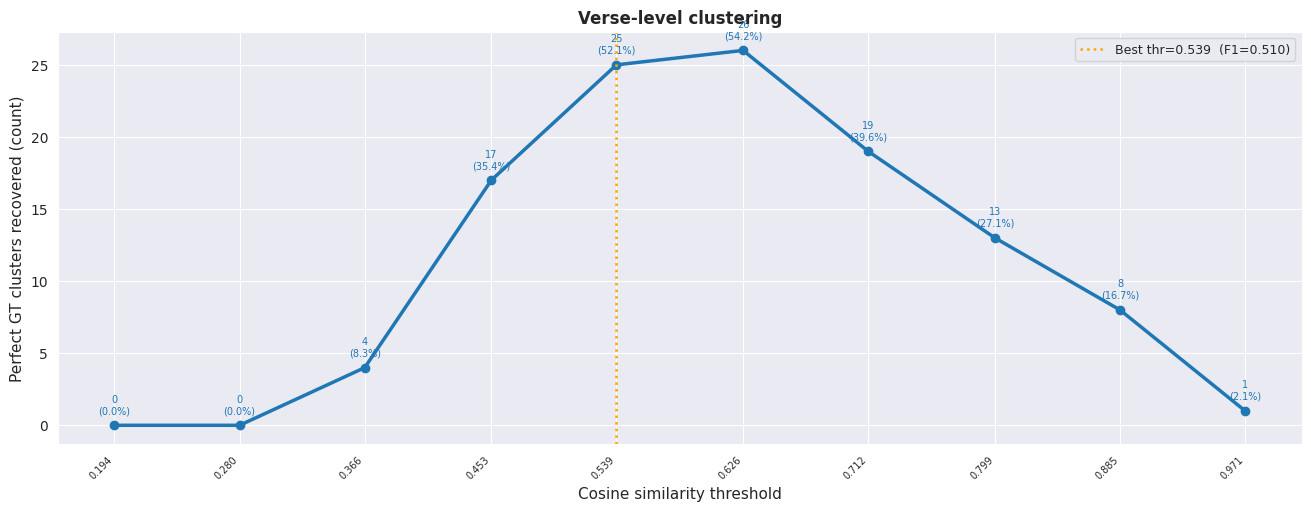


Poem-level clustering (Jaccard on verse cluster id sets)
Jaccard pairs: 17,495 in 0.01s
Sweeping 10 thresholds: 0.167 to 0.990
  0.167  perfect=     9 (60.0%)  recall=0.600  prec=0.818  f1=0.692  [0.004s]
  0.258  perfect=     9 (60.0%)  recall=0.600  prec=0.750  f1=0.667  [0.003s]
  0.350  perfect=     7 (46.7%)  recall=0.467  prec=0.538  f1=0.500  [0.002s]
  0.441  perfect=     6 (40.0%)  recall=0.400  prec=0.429  f1=0.414  [0.002s]
  0.533  perfect=     3 (20.0%)  recall=0.200  prec=0.111  f1=0.143  [0.001s]
  0.624  perfect=     3 (20.0%)  recall=0.200  prec=0.111  f1=0.143  [0.001s]
  0.716  perfect=     1 (6.7%)  recall=0.067  prec=0.031  f1=0.043  [0.001s]
  0.807  perfect=     1 (6.7%)  recall=0.067  prec=0.030  f1=0.042  [0.001s]
  0.899  perfect=     1 (6.7%)  recall=0.067  prec=0.031  f1=0.043  [0.001s]
  0.990  perfect=     1 (6.7%)  recall=0.067  prec=0.031  f1=0.043  [0.001s]

Best poem:  thr=0.167  f1=0.692  recall=0.600  precision=0.818  perfect=9 (60.0% of GT)


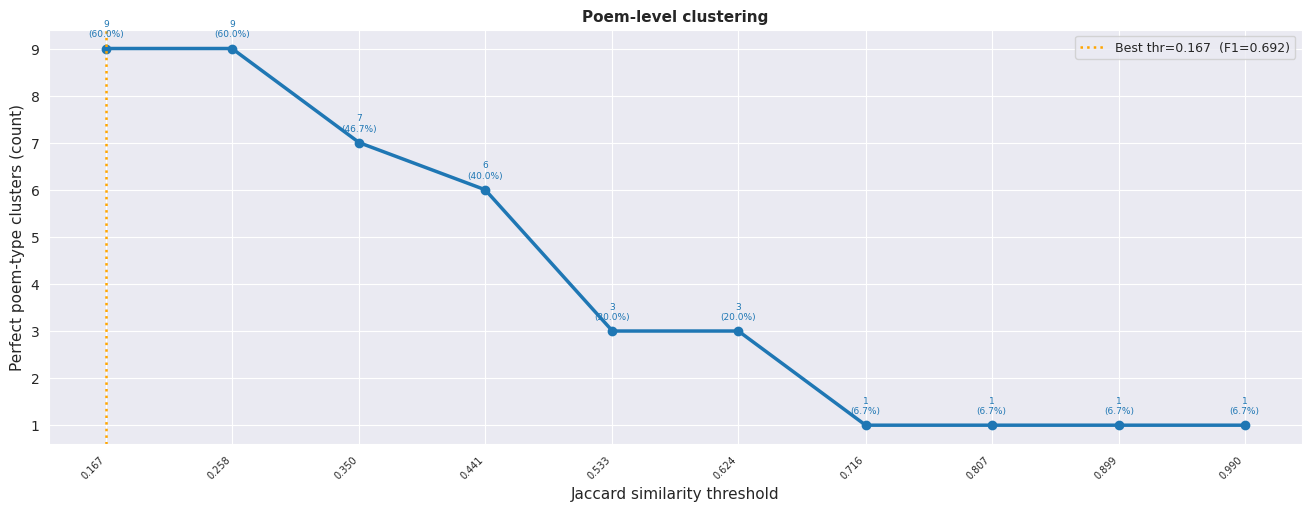

In [8]:
import re
import time
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import faiss
from transformers import AutoTokenizer, AutoModel
from collections import defaultdict
from typing import List

MODEL_NAME      = 'kevinkrahn/shlm-grc-en'
GT_COL          = 'idgroup'
POEM_COL        = 'idoriginal_poem'
TYPE_COL        = 'type_id'
TEXT_COL        = 'verse'
MIN_TEXT_TOKENS = 6
ABTT_COMPONENTS = 10
FAISS_K         = 200
FAISS_NLIST     = 100
FAISS_NPROBE    = 50
CACHE_DIR       = './.cache'
EMBED_BATCH     = 1024

def _detect_device() -> torch.device:
    if torch.cuda.is_available():
        try:
            t = torch.zeros(1, device='cuda')
            del t
            print('GPU detected — running on CUDA.')
            return torch.device('cuda')
        except Exception as e:
            print(f'CUDA advertised but unusable ({e}); falling back to CPU.')
    else:
        print('No CUDA device found — running on CPU.')
    return torch.device('cpu')

device   = _detect_device()
USE_GPU  = device.type == 'cuda'


def _build_faiss_index(emb: np.ndarray, nlist: int, nprobe: int):
    dim = emb.shape[1]
    if USE_GPU:
        res = faiss.StandardGpuResources()
        cfg = faiss.GpuIndexIVFFlatConfig()
        cfg.device = 0
        index = faiss.GpuIndexIVFFlat(res, dim, nlist,
                                       faiss.METRIC_INNER_PRODUCT, cfg)
        index.train(emb)
        index.add(emb)
        cpu_index = faiss.index_gpu_to_cpu(index)
        cpu_index.nprobe = nprobe
        gpu_index = faiss.index_cpu_to_gpu(res, 0, cpu_index)
        return gpu_index
    else:
        if len(emb) >= nlist * 10:
            quantizer = faiss.IndexFlatIP(dim)
            index = faiss.IndexIVFFlat(quantizer, dim, nlist,
                                        faiss.METRIC_INNER_PRODUCT)
            index.train(emb)
            index.nprobe = nprobe
        else:
            print(f'  Dataset too small for IVF (need ≥{nlist*10} rows); '
                  f'using exact FlatIP index instead.')
            index = faiss.IndexFlatIP(dim)
        index.add(emb)
        return index

class TextPreprocessor:
    def __init__(self, lowercase=True, remove_punctuation=True,
                 remove_diacritics=True):
        self.lowercase          = lowercase
        self.remove_punctuation = remove_punctuation
        self.remove_diacritics  = remove_diacritics
        if remove_punctuation:
            self.punct_pattern        = re.compile(r'[^\w\s]', re.UNICODE)
            self.remove_chars_pattern = re.compile(r'[\(\)\{\}]')

    def _remove_diacritics(self, text):
        return ''.join(c for c in unicodedata.normalize('NFD', text)
                       if unicodedata.category(c) != 'Mn')

    def preprocess(self, text):
        if not isinstance(text, str):
            text = str(text) if pd.notna(text) else ''
        if self.remove_diacritics:  text = self._remove_diacritics(text)
        if self.lowercase:          text = text.lower()
        if self.remove_punctuation:
            text = self.remove_chars_pattern.sub('', text)
            text = self.punct_pattern.sub(' ', text)
        return ' '.join(text.split())

    def preprocess_batch(self, texts: List[str]) -> List[str]:
        return [self.preprocess(t) for t in texts]


preprocessor = TextPreprocessor(lowercase=True, remove_punctuation=False,
                                 remove_diacritics=False)

df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=[GT_COL]).copy()
df[TEXT_COL] = preprocessor.preprocess_batch(df[TEXT_COL].tolist())
df[GT_COL]   = df[GT_COL].astype(str)
df[TEXT_COL] = df[TEXT_COL].fillna('').astype(str)
df = df.drop_duplicates(subset='id', keep='first').reset_index(drop=True)
df = df[df[TEXT_COL].apply(lambda t: len(t.split()) >= MIN_TEXT_TOKENS)].copy()
df[TEXT_COL] = df[TEXT_COL].apply(lambda t: unicodedata.normalize('NFKC', t))
df = df.reset_index(drop=True)
N  = len(df)
print(f'Rows after filter: {N:,}')

model     = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True,
                                       cache_dir=CACHE_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True,
                                           cache_dir=CACHE_DIR)
model.eval().to(device)

def embed_verses(texts: List[str]) -> np.ndarray:
    print(f'Embedding {len(texts):,} verses on {device} ...')
    t0, vecs_all = time.time(), []
    for s in range(0, len(texts), EMBED_BATCH):
        batch = texts[s:s + EMBED_BATCH]
        enc   = tokenizer(batch, padding=True, truncation=True,
                          max_length=128, return_tensors='pt')

        if USE_GPU:
            enc = {k: v.pin_memory().to(device, non_blocking=True)
                   for k, v in enc.items()}
        else:
            enc = {k: v.to(device) for k, v in enc.items()}

        if USE_GPU:
            ctx = torch.cuda.amp.autocast()
        else:
            from contextlib import nullcontext
            ctx = nullcontext()

        with torch.no_grad(), ctx:
            out = model(**enc)

        v = torch.nn.functional.normalize(out[0][:, 0].float(), dim=1)
        vecs_all.append(v.cpu())

        step = s // EMBED_BATCH
        if step % 10 == 0:
            print(f'  {min(s + EMBED_BATCH, len(texts))}/{len(texts)}',
                  end='\r', flush=True)

    print(f'\n  done in {time.time()-t0:.1f}s')
    return torch.cat(vecs_all).numpy().astype(np.float32)


raw_emb = embed_verses(df[TEXT_COL].tolist())

print('Applying ABTT ...')
t0 = time.time()
E  = torch.from_numpy(raw_emb).to(device)
E  = E - E.mean(dim=0, keepdim=True)
_, _, Vh = torch.linalg.svd(E, full_matrices=False)
top_directions = Vh[:ABTT_COMPONENTS]
E  = E - (E @ top_directions.T) @ top_directions
E  = torch.nn.functional.normalize(E, dim=1)
emb = E.cpu().numpy().astype(np.float32)
DIM = emb.shape[1]
print(f'ABTT done in {time.time()-t0:.1f}s')

print('Building FAISS index ...')
t0    = time.time()
index = _build_faiss_index(emb, FAISS_NLIST, FAISS_NPROBE)
dsts, nbrs = index.search(emb, FAISS_K + 1)
print(f'FAISS built+searched in {time.time()-t0:.1f}s')

gt_multi = {frozenset(idxs)
            for idxs in df.groupby(GT_COL).groups.values()
            if len(idxs) >= 2}

src_all  = np.repeat(np.arange(N, dtype=np.int32), FAISS_K)
dst_all  = nbrs[:, 1:FAISS_K+1].ravel().astype(np.int32)
sims_all = dsts[:, 1:FAISS_K+1].ravel().astype(np.float32)
upper    = dst_all > src_all
valid    = dst_all >= 0

order  = np.argsort(-sims_all)
src_s  = src_all[order];  dst_s  = dst_all[order]
sim_s  = sims_all[order]; up_s   = upper[order]; val_s = valid[order]


def build_clusters(sim_thr):
    mask   = (sim_s >= sim_thr) & up_s & val_s
    parent = np.arange(N, dtype=np.int32)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x

    for a, b in zip(src_s[mask].tolist(), dst_s[mask].tolist()):
        pa, pb = find(a), find(b)
        if pa != pb: parent[pa] = pb
    groups = defaultdict(set)
    for i in range(N): groups[find(i)].add(i)
    return [frozenset(g) for g in groups.values()]


knn_sims = sims_all[sims_all > 0]
p1_sim   = float(np.percentile(knn_sims, 50))
p99_sim  = float(np.percentile(knn_sims, 99))
SIM_THRESHOLDS = np.round(
    np.linspace(max(0.01, p1_sim), min(0.99, p99_sim), num=10), 3
).tolist()
print(f'\nVerse grid search over {len(SIM_THRESHOLDS)} thresholds: '
      f'{SIM_THRESHOLDS[0]:.3f} to {SIM_THRESHOLDS[-1]:.3f}')

verse_results = []
best_verse_clusters, best_verse_f1 = None, -1

for sim_thr in SIM_THRESHOLDS:
    t0         = time.time()
    clusters   = build_clusters(sim_thr)
    pred_multi = {c for c in clusters if len(c) >= 2}
    perfect    = pred_multi & gt_multi
    recall     = len(perfect) / len(gt_multi)   if gt_multi   else 0.0
    precision  = len(perfect) / len(pred_multi) if pred_multi else 0.0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)
    pct = 100 * len(perfect) / len(gt_multi) if gt_multi else 0
    print(f'  {sim_thr:.3f}  perfect={len(perfect):6d} ({pct:.1f}%)  '
          f'recall={recall:.3f}  prec={precision:.3f}  f1={f1:.3f}'
          f'  [{time.time()-t0:.3f}s]')
    verse_results.append({'sim_thr': sim_thr, 'perfect': len(perfect),
                          'recall': recall, 'precision': precision, 'f1': f1,
                          'n_pred_multi': len(pred_multi)})
    if f1 > best_verse_f1:
        best_verse_f1, best_verse_clusters = f1, clusters

verse_df   = pd.DataFrame(verse_results)
best_verse = verse_df.loc[verse_df['f1'].idxmax()]
print(f'\nBest verse:  sim_thr={best_verse.sim_thr}  f1={best_verse.f1:.3f}  '
      f'recall={best_verse.recall:.3f}  precision={best_verse.precision:.3f}  '
      f'perfect={int(best_verse.perfect)}'
      f' ({100*best_verse.perfect/len(gt_multi):.1f}% of GT)')

fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
ax.plot(verse_df['sim_thr'], verse_df['perfect'],
        marker='o', lw=2.5, color='#1f77b4')
for _, r in verse_df.iterrows():
    pct = 100 * r['perfect'] / len(gt_multi) if gt_multi else 0
    ax.annotate(f'{int(r["perfect"])}\n({pct:.1f}%)',
                xy=(r.sim_thr, r['perfect']),
                xytext=(0, 7), textcoords='offset points',
                ha='center', va='bottom', fontsize=7, color='#1f77b4')
ax.axvline(best_verse.sim_thr, color='orange', lw=1.8, ls=':',
           label=f'Best thr={best_verse.sim_thr:.3f}  (F1={best_verse.f1:.3f})')
ax.set_xlabel('Cosine similarity threshold', fontsize=11)
ax.set_ylabel('Perfect GT clusters recovered (count)', fontsize=11)
ax.set_xticks(verse_df['sim_thr'])
ax.set_xticklabels([f'{t:.3f}' for t in verse_df['sim_thr']],
                   rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=9)
ax.set_title('Verse-level clustering', fontsize=12, fontweight='bold')
plt.savefig('verse_linechart_plaintext.png', dpi=150, bbox_inches='tight')
plt.show()

verse_cid = np.full(N, -1, dtype=np.int32)
for cid, cluster in enumerate(best_verse_clusters):
    for i in cluster: verse_cid[i] = cid
df['verse_cluster_id'] = verse_cid

poem_type = df.drop_duplicates(POEM_COL).set_index(POEM_COL)[TYPE_COL].to_dict()
gt_poem_multi = {
    frozenset(pids) for pids in
    pd.Series(poem_type).groupby(pd.Series(poem_type)).groups.values()
    if len(pids) >= 2
}

poem_vclusters = (
    df.groupby(POEM_COL)['verse_cluster_id']
      .apply(lambda s: frozenset(s[s != -1].values))
      .to_dict()
)

print(f'\nPoem-level clustering (Jaccard on verse cluster id sets)')
t0 = time.time()
cid_to_poems = defaultdict(list)
for pid, vcids in poem_vclusters.items():
    for cid in vcids: cid_to_poems[cid].append(pid)

pair_sim = {}
for pids in cid_to_poems.values():
    if len(pids) < 2: continue
    pids_s = sorted(pids)
    for i in range(len(pids_s)):
        for j in range(i + 1, len(pids_s)):
            a, b = pids_s[i], pids_s[j]
            if (a, b) not in pair_sim:
                union = poem_vclusters[a] | poem_vclusters[b]
                if union:
                    pair_sim[(a, b)] = (
                        len(poem_vclusters[a] & poem_vclusters[b]) / len(union)
                    )
print(f'Jaccard pairs: {len(pair_sim):,} in {time.time()-t0:.2f}s')

pairs_sorted  = sorted(pair_sim.items(), key=lambda x: -x[1])
pair_sims_arr = np.array([s for _, s in pairs_sorted], dtype=np.float32)
pair_keys     = [k for k, _ in pairs_sorted]


def cluster_poems(threshold):
    cutoff   = int(np.searchsorted(-pair_sims_arr, -threshold))
    pid_list = list(poem_vclusters.keys())
    parent   = {p: p for p in pid_list}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x

    for a, b in pair_keys[:cutoff]:
        pa, pb = find(a), find(b)
        if pa != pb: parent[pa] = pb
    groups = defaultdict(set)
    for pid in pid_list: groups[find(pid)].add(pid)
    return {frozenset(g) for g in groups.values() if len(g) >= 2}


sims_arr = np.array(list(pair_sim.values())) if pair_sim else np.array([])
if len(sims_arr):
    p1, p99 = float(np.percentile(sims_arr, 1)), float(np.percentile(sims_arr, 99))
    POEM_THRESHOLDS = np.round(
        np.linspace(max(0.05, p1), min(0.99, p99), num=10), 3
    ).tolist()
else:
    POEM_THRESHOLDS = [0.1, 0.3, 0.5, 0.7, 0.9]
print(f'Sweeping {len(POEM_THRESHOLDS)} thresholds: '
      f'{POEM_THRESHOLDS[0]:.3f} to {POEM_THRESHOLDS[-1]:.3f}')

poem_results = []
for thr in POEM_THRESHOLDS:
    t0        = time.time()
    pred      = cluster_poems(thr)
    perfect   = pred & gt_poem_multi
    recall    = len(perfect) / len(gt_poem_multi) if gt_poem_multi else 0.0
    precision = len(perfect) / len(pred)          if pred          else 0.0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)
    pct = 100 * len(perfect) / len(gt_poem_multi) if gt_poem_multi else 0
    print(f'  {thr:.3f}  perfect={len(perfect):6d} ({pct:.1f}%)  '
          f'recall={recall:.3f}  prec={precision:.3f}  f1={f1:.3f}'
          f'  [{time.time()-t0:.3f}s]')
    poem_results.append({'threshold': thr, 'perfect': len(perfect),
                         'n_pred_multi': len(pred),
                         'recall': recall, 'precision': precision, 'f1': f1})

poem_df   = pd.DataFrame(poem_results)
best_poem = poem_df.loc[poem_df['f1'].idxmax()]
print(f'\nBest poem:  thr={best_poem.threshold}  f1={best_poem.f1:.3f}  '
      f'recall={best_poem.recall:.3f}  precision={best_poem.precision:.3f}  '
      f'perfect={int(best_poem.perfect)}'
      f' ({100*best_poem.perfect/len(gt_poem_multi):.1f}% of GT)')

fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
ax.plot(poem_df['threshold'], poem_df['perfect'],
        marker='o', lw=2.5, color='#1f77b4')
for _, r in poem_df.iterrows():
    pct = 100 * r['perfect'] / len(gt_poem_multi) if gt_poem_multi else 0
    ax.annotate(f'{int(r["perfect"])}\n({pct:.1f}%)',
                xy=(r.threshold, r['perfect']),
                xytext=(0, 7), textcoords='offset points',
                ha='center', va='bottom', fontsize=6.5, color='#1f77b4')
ax.axvline(best_poem.threshold, color='orange', lw=1.8, ls=':',
           label=f'Best thr={best_poem.threshold:.3f}  (F1={best_poem.f1:.3f})')
ax.set_xlabel('Jaccard similarity threshold', fontsize=11)
ax.set_ylabel('Perfect poem-type clusters (count)', fontsize=11)
ax.set_xticks(poem_df['threshold'])
ax.set_xticklabels([f'{t:.3f}' for t in poem_df['threshold']],
                   rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=9)
ax.set_title('Poem-level clustering', fontsize=11, fontweight='bold')
plt.savefig('poem_linechart_plaintext.png', dpi=150, bbox_inches='tight')
plt.show()

# Full ds

## Orth

In [ ]:
import gc
import re
import time
import unicodedata
import warnings
from pathlib import Path
from collections import defaultdict, Counter
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

CSV_PATH            = '~/Downloads/concatenated.csv'
OUT_DIR             = Path('.')
CACHE_DIR           = Path('.lsh_cache')

NUM_PERM            = 128
N_BANDS             = 16
POEM_SAMPLE_N       = 10_000
MIN_VERSES_PER_POEM = 2
MAX_VERSES_PER_POEM = 10

SHINGLE_SIZES   = [2, 3, 4, 5]
THRESHOLDS      = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

W_DBI  = 0.40
W_SIL  = 0.35
W_NSR  = 0.25
NSR_LO = 0.10
NSR_HI = 0.50

DBI_CLUSTER_CAP = 200
INTER_PAIRS     = 2_000
GPU_BATCH       = 50_000
SIG_CHUNK       = 100_000
RANDOM_SEED     = 42

MIN_WORDS_PER_VERSE = 6
MAX_WORDS_PER_VERSE = 50

CACHE_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

class TextPreprocessor:
    _GAP_RE = re.compile(
        r'\[[^\]]{0,40}\]'
        r'|<[^>]{0,40}>'
        r'|\{[^}]{0,40}\}'
        r'|\.{2,}'
        r'|-{2,}'
        r'|\*{2,}'
        r'|#{2,}'
        r'|\?{2,}',
        re.UNICODE
    )
    _PUNCT_RE = re.compile(r'[^\w\s]', re.UNICODE)
    _SPACE_RE = re.compile(r'\s+')

    def __init__(self, lowercase=True, remove_punctuation=True,
                 remove_diacritics=True):
        self.lowercase          = lowercase
        self.remove_punctuation = remove_punctuation
        self.remove_diacritics  = remove_diacritics

    def _strip_diacritics(self, text: str) -> str:
        return ''.join(
            c for c in unicodedata.normalize('NFD', text)
            if unicodedata.category(c) != 'Mn'
        )

    def preprocess(self, text) -> str:
        if not isinstance(text, str):
            text = str(text) if pd.notna(text) else ''
        text = self._GAP_RE.sub(' ', text)
        if self.remove_diacritics:
            text = self._strip_diacritics(text)
        if self.lowercase:
            text = text.lower()
        if self.remove_punctuation:
            text = self._PUNCT_RE.sub(' ', text)
        return self._SPACE_RE.sub(' ', text).strip()

    def preprocess_batch(self, texts: List[str]) -> List[str]:
        return [self.preprocess(t) for t in texts]


preprocessor = TextPreprocessor(
    lowercase=True,
    remove_punctuation=True,
    remove_diacritics=True,
)

try:
    import cupy as cp
    cp.array([1])
    GPU = True
    dev = cp.cuda.Device(0)
    free, total = dev.mem_info
    print(f'GPU: {cp.cuda.runtime.getDeviceProperties(0)["name"].decode()}  '
          f'VRAM free: {free/1e9:.1f} / {total/1e9:.1f} GB')
except Exception as e:
    cp = None; GPU = False
    print(f'CuPy unavailable ({e}) - using CPU.')

def load_npy_cache(path, compute_fn):
    path = Path(path)
    if path.exists():
        print(f'  [cache] {path.name}'); return np.load(path)
    r = compute_fn(); np.save(path, r); return r

def load_csv_cache(path, compute_fn):
    path = Path(path)
    if path.exists():
        print(f'  [cache] {path.name}'); return pd.read_csv(path)
    r = compute_fn(); r.to_csv(path, index=False); return r

def open_mmap(path, n, p, mode='r'):
    return np.memmap(path, dtype=np.uint32, mode=mode, shape=(n, p))

t0 = time.time()
df = pd.read_csv(CSV_PATH, low_memory=False)
df.columns = df.columns.str.strip().str.lower()

RENAME = {'idoriginal_poem': 'idoriginal_poem', 'original_poem_id': 'idoriginal_poem',
          'order': 'order', 'source_dataset': 'source_dataset'}
for c in df.columns:
    if 'verse' in c and 'id' not in c:
        RENAME[c] = 'verse'
df.rename(columns={k: v for k, v in RENAME.items() if k in df.columns}, inplace=True)
for req in ['verse', 'idoriginal_poem', 'source_dataset']:
    if req not in df.columns:
        raise ValueError(f'Missing column: {req}')

df = df.dropna(subset=['verse']).copy()
df['verse']           = df['verse'].astype(str).str.strip()
df['idoriginal_poem'] = df['idoriginal_poem'].astype(str)
df['source_dataset']  = df['source_dataset'].astype(str)

df['verse'] = preprocessor.preprocess_batch(df['verse'].tolist())

df = df[df['verse'].str.len() >= 5].reset_index(drop=True)
N_full = len(df)
print(f'Loaded and preprocessed: {time.time()-t0:.1f}s | {N_full:,} rows | '
      f'{df["source_dataset"].nunique()} datasets.')
print(df['source_dataset'].value_counts().to_string())

word_counts = df['verse'].str.split().str.len()
before      = len(df)
df          = df[(word_counts >= MIN_WORDS_PER_VERSE) &
                 (word_counts <= MAX_WORDS_PER_VERSE)].reset_index(drop=True)
print(f'Word filter ({MIN_WORDS_PER_VERSE}-{MAX_WORDS_PER_VERSE}): '
      f'{before:,} to {len(df):,} rows.')
print(df['source_dataset'].value_counts().to_string())

poem_sizes  = df.groupby('idoriginal_poem').size().rename('n_verses')
poem_source = (df.drop_duplicates('idoriginal_poem')
                 .set_index('idoriginal_poem')['source_dataset'])
poem_meta = pd.DataFrame({'n_verses': poem_sizes, 'source_dataset': poem_source})
poem_meta = poem_meta[
    (poem_meta['n_verses'] >= MIN_VERSES_PER_POEM) &
    (poem_meta['n_verses'] <= MAX_VERSES_PER_POEM)
].reset_index()

N_eligible_poems = len(poem_meta)
print(f'Eligible poems ({MIN_VERSES_PER_POEM}-{MAX_VERSES_PER_POEM} verses): {N_eligible_poems:,}.')
print(poem_meta.groupby('source_dataset')['n_verses']
      .agg(['count', 'mean', 'median'])
      .rename(columns={'count': 'poems', 'mean': 'mean_v', 'median': 'med_v'})
      .to_string())

def stratified_sample_poems(meta_df, n, seed=RANDOM_SEED):
    counts = meta_df['source_dataset'].value_counts(normalize=True)
    rng_   = np.random.default_rng(seed)
    parts  = []
    for src, prop in counts.items():
        pool = meta_df[meta_df['source_dataset'] == src]
        take = min(max(1, round(prop * n)), len(pool))
        chosen = pool.iloc[rng_.choice(len(pool), size=take, replace=False)]
        parts.append(chosen)
    result = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    if len(result) < n:
        used  = set(result['idoriginal_poem'])
        avail = meta_df[~meta_df['idoriginal_poem'].isin(used)]
        extra = min(n - len(result), len(avail))
        if extra > 0:
            result = pd.concat(
                [result, avail.sample(extra, random_state=seed + 1)],
                ignore_index=True)
    return result.reset_index(drop=True)

n_to_sample   = min(POEM_SAMPLE_N, N_eligible_poems)
sampled_poems = stratified_sample_poems(poem_meta, n_to_sample)
sampled_pids  = set(sampled_poems['idoriginal_poem'])

sample_df     = df[df['idoriginal_poem'].isin(sampled_pids)].copy().reset_index(drop=True)
SAMPLE_VERSES = sample_df['verse'].tolist()
N_SAMPLE      = len(SAMPLE_VERSES)

print(f'Sampled poems: {len(sampled_pids):,}.')
print(f'Sampled verses: {N_SAMPLE:,}  (mean {N_SAMPLE/len(sampled_pids):.1f} verses/poem).')
print(sample_df.groupby('source_dataset').agg(
    poems=('idoriginal_poem', 'nunique'),
    verses=('verse', 'count')
).to_string())

GS_VERSES = SAMPLE_VERSES
GS_N      = N_SAMPLE
print(f'Verse GS verses: {GS_N:,}.')

_MP  = np.int64((1 << 61) - 1)
_MH  = np.int64((1 << 32) - 1)
rng  = np.random.RandomState(1)
_A   = rng.randint(1, int(_MP), NUM_PERM, dtype=np.int64)
_B   = rng.randint(0, int(_MP), NUM_PERM, dtype=np.int64)
_FNV_PRIME  = np.int64(16777619)
_FNV_OFFSET = np.int64(2166136261)


def build_signatures_gpu(verses, k, A_gpu, B_gpu):
    B_  = len(verses); P = A_gpu.shape[0]
    MP  = cp.int64(_MP); MH = cp.int64(_MH)
    FP  = cp.int64(_FNV_PRIME); FO = cp.int64(_FNV_OFFSET)
    encoded = [v.lower().encode('utf-8') for v in verses]
    lengths = np.array([len(e) for e in encoded], dtype=np.int32)
    max_len = int(lengths.max()) if len(lengths) else 0
    if max_len == 0:
        return np.full((B_, P), int(_MH), dtype=np.uint32)
    byte_mat = np.zeros((B_, max_len), dtype=np.uint8)
    for i, e in enumerate(encoded):
        byte_mat[i, :len(e)] = np.frombuffer(e, dtype=np.uint8)
    g_bytes   = cp.asarray(byte_mat)
    g_lengths = cp.asarray(lengths)
    max_sh    = max(1, max_len - k + 1)
    starts    = cp.arange(max_sh, dtype=cp.int32)
    sh_hash   = cp.full((B_, max_sh), FO, dtype=cp.int64)
    for byte_pos in range(k):
        col_idx  = starts[cp.newaxis, :] + byte_pos
        in_range = col_idx < g_lengths[:, cp.newaxis]
        safe_col = cp.clip(col_idx, 0, max_len - 1)
        bvals    = g_bytes[cp.arange(B_, dtype=cp.int32)[:, cp.newaxis],
                           safe_col].astype(cp.int64)
        sh_hash  = cp.where(in_range, ((sh_hash ^ bvals) * FP) & MH, sh_hash)
    valid   = (starts[cp.newaxis, :] + k - 1) < g_lengths[:, cp.newaxis]
    sh_hash = cp.where(valid, sh_hash, MH)
    sig     = cp.full((B_, P), MH, dtype=cp.int64)
    for s in range(max_sh):
        h     = sh_hash[:, s]
        uhash = (A_gpu[cp.newaxis, :] * h[:, cp.newaxis]
                 + B_gpu[cp.newaxis, :]) % MP & MH
        sig   = cp.minimum(sig, uhash)
    result = cp.asnumpy(sig.astype(cp.uint32))
    del g_bytes, g_lengths, sh_hash, sig
    cp.get_default_memory_pool().free_all_blocks()
    return result


def build_signatures_cpu(verses, k):
    try:
        import xxhash
        def _h(s): return xxhash.xxh32(s.encode()).intdigest()
    except ImportError:
        def _h(s):
            v = 2166136261
            for c in s.encode(): v = ((v ^ c) * 16777619) & 0xFFFFFFFF
            return v
    out = []
    for text in verses:
        t = text.lower(); n = len(t)
        if n == 0:
            out.append(np.full(NUM_PERM, int(_MH), dtype=np.uint32)); continue
        sh  = np.array([_h(t[i:i+k]) for i in range(max(n-k+1, 1))], dtype=np.int64)
        sig = ((_A[None,:]*sh[:,None]+_B[None,:]) % int(_MP) & int(_MH)).min(0).astype(np.uint32)
        out.append(sig)
    return np.stack(out)


def build_signatures_mmap(verses, k, num_perm=NUM_PERM):
    n    = len(verses)
    path = CACHE_DIR / f'sigs_k{k}_n{n}_p{num_perm}.dat'
    if path.exists():
        print(f'  [cache] {path.name}')
        return open_mmap(path, n, num_perm)
    mmap = open_mmap(path, n, num_perm, 'w+')
    if GPU:
        A_gpu = cp.asarray(_A); B_gpu = cp.asarray(_B); t0_ = time.time()
        for start in range(0, n, GPU_BATCH):
            end = min(start + GPU_BATCH, n)
            mmap[start:end] = build_signatures_gpu(verses[start:end], k, A_gpu, B_gpu)
            print(f'  k={k}  {end:,}/{n:,}', end='\r', flush=True)
        del A_gpu, B_gpu
        cp.get_default_memory_pool().free_all_blocks()
    else:
        for start in range(0, n, SIG_CHUNK):
            end = min(start + SIG_CHUNK, n)
            mmap[start:end] = build_signatures_cpu(verses[start:end], k)
            print(f'  k={k}  {end:,}/{n:,} (CPU)', end='\r', flush=True)
    mmap.flush()
    print(f'  k={k}  done -> {path.name}          ')
    return open_mmap(path, n, num_perm)


_BUCKET_BROADCAST_MAX = 256

def make_union_find(n): return np.arange(n, dtype=np.int32)

def union_find_root(p, x):
    while p[x] != x: p[x] = p[p[x]]; x = p[x]
    return x

def union_find_merge(p, x, y):
    px, py = union_find_root(p, x), union_find_root(p, y)
    if px != py: p[px] = py

def lsh_cluster_filtered(sigs, n_bands, threshold):
    N_, P = sigs.shape; bw = P // n_bands
    par   = make_union_find(N_)
    sims  = []

    for b in range(n_bands):
        band  = np.array(sigs[:, b*bw:(b+1)*bw], dtype=np.int64)
        keys  = np.zeros(N_, dtype=np.int64)
        for col in range(bw):
            keys = (keys * 1000003 + band[:, col]) & 0x7FFFFFFFFFFFFFFF
        del band
        order = np.argsort(keys, kind='stable'); sk = keys[order]
        brk   = np.flatnonzero(np.diff(sk)) + 1

        for s, e in zip(np.concatenate([[0], brk]),
                        np.concatenate([brk, [N_]])):
            if e - s < 2: continue
            bucket = order[s:e]
            rows   = np.array(sigs[bucket], dtype=np.uint32)
            B      = len(bucket)

            if B <= _BUCKET_BROADCAST_MAX:
                eq        = (rows[:, None, :] == rows[None, :, :]).sum(axis=2)
                jac       = eq.astype(np.float32) / P
                ii, jj    = np.triu_indices(B, k=1)
                pair_sims = jac[ii, jj]
                mask      = pair_sims >= threshold
                for a, b_idx in zip(ii[mask], jj[mask]):
                    union_find_merge(par, int(bucket[a]), int(bucket[b_idx]))
                sims.extend(pair_sims[mask].tolist())
            else:
                for bi in range(B):
                    eq_row  = (rows[bi][None, :] == rows[bi+1:]).sum(axis=1)
                    jac_row = eq_row.astype(np.float32) / P
                    above   = np.where(jac_row >= threshold)[0]
                    for off in above:
                        union_find_merge(par, int(bucket[bi]), int(bucket[bi + 1 + off]))
                        sims.append(float(jac_row[off]))

    return par, sims


def parent_to_clusters(par):
    g = defaultdict(set)
    for i in range(len(par)): g[union_find_root(par, i)].add(i)
    return {frozenset(v) for v in g.values()}


def nsr_peaked_score(nsr):
    mid  = (NSR_LO + NSR_HI) / 2
    half = (NSR_HI - NSR_LO) / 2
    return float(np.clip(1.0 - ((nsr - mid) / half) ** 2, 0.0, 1.0))


def compute_clustering_metrics(par, sims, sigs, n_verses):
    rng_         = np.random.default_rng(RANDOM_SEED)
    P            = sigs.shape[1]
    labels       = np.array([union_find_root(par, i) for i in range(n_verses)], dtype=np.int32)
    unique_roots, sizes = np.unique(labels, return_counts=True)
    n_multi      = int((sizes >= 2).sum())
    nsr          = float(sizes[sizes >= 2].sum() / n_verses)

    intra_global = float(np.mean(sims)) if sims else 0.0

    cluster_list = [np.array(list(frozenset(np.where(labels == r)[0])), dtype=np.int32)
                    for r, sz in zip(unique_roots, sizes) if sz >= 2]
    inter_global = 0.0
    if len(cluster_list) >= 2:
        ci   = rng_.integers(0, len(cluster_list), INTER_PAIRS)
        cj   = rng_.integers(0, len(cluster_list), INTER_PAIRS)
        same = ci == cj; cj[same] = (cj[same] + 1) % len(cluster_list)
        vi   = np.array([cluster_list[c][rng_.integers(0, len(cluster_list[c]))]
                          for c in ci], dtype=np.int32)
        vj   = np.array([cluster_list[c][rng_.integers(0, len(cluster_list[c]))]
                          for c in cj], dtype=np.int32)
        si   = np.array(sigs[vi], dtype=np.uint32)
        sj   = np.array(sigs[vj], dtype=np.uint32)
        inter_global = float((si == sj).sum(axis=1).mean()) / P

    sil = intra_global / (intra_global + inter_global + 1e-12)

    cap_clusters = cluster_list[:DBI_CLUSTER_CAP]
    per_cluster_intra = []
    for cl in cap_clusters:
        if len(cl) == 1:
            per_cluster_intra.append(0.0); continue
        n_pairs = min(50, len(cl) * (len(cl) - 1) // 2)
        if n_pairs == 0:
            per_cluster_intra.append(1.0); continue
        idx_a = rng_.integers(0, len(cl), n_pairs)
        idx_b = rng_.integers(0, len(cl), n_pairs)
        same  = idx_a == idx_b
        idx_b[same] = (idx_b[same] + 1) % len(cl)
        va = np.array(sigs[cl[idx_a]], dtype=np.uint32)
        vb = np.array(sigs[cl[idx_b]], dtype=np.uint32)
        per_cluster_intra.append(float((va == vb).sum(axis=1).mean()) / P)
    per_cluster_intra = np.array(per_cluster_intra, dtype=np.float32)
    spreads = 1.0 - per_cluster_intra

    K = len(cap_clusters)
    dbi_val = 0.0
    if K >= 2:
        ratio_max = np.zeros(K, dtype=np.float32)
        for i in range(K):
            for j in range(i + 1, K):
                vi_ = cap_clusters[i][rng_.integers(0, len(cap_clusters[i]))]
                vj_ = cap_clusters[j][rng_.integers(0, len(cap_clusters[j]))]
                sep_ij = 1.0 - float((sigs[vi_] == sigs[vj_]).sum()) / P
                ratio  = (spreads[i] + spreads[j]) / max(sep_ij, 1e-6)
                if ratio > ratio_max[i]: ratio_max[i] = ratio
                if ratio > ratio_max[j]: ratio_max[j] = ratio
        dbi_val = float(ratio_max.mean())

    dbi_score = 1.0 / (1.0 + dbi_val)
    composite = W_DBI * dbi_score + W_SIL * sil + W_NSR * nsr_peaked_score(nsr)

    return {
        'intra':      intra_global,
        'inter':      inter_global,
        'sil':        sil,
        'dbi':        dbi_val,
        'dbi_score':  dbi_score,
        'nsr':        nsr,
        'nsr_peaked': nsr_peaked_score(nsr),
        'composite':  composite,
        'n_multi':    n_multi,
        'n_clusters': len(unique_roots),
        'max_size':   int(sizes.max()) if len(sizes) else 0,
    }


print(f'\nVerse grid search: verses={GS_N:,}  poems={len(sampled_pids):,}.')
GS_RAW_CACHE = CACHE_DIR / f'verse_gs_dbi_n{GS_N}.csv'

def run_verse_grid_search():
    print('Building sample signatures ...')
    t = time.time()
    sample_sigs = {}
    for k in SHINGLE_SIZES:
        mmap = build_signatures_mmap(GS_VERSES, k)
        sample_sigs[k] = np.array(mmap)
    print(f'Signatures built: {time.time()-t:.1f}s.')

    rows = []
    for k in SHINGLE_SIZES:
        sigs = sample_sigs[k]
        print(f'  k={k}')
        for thresh in THRESHOLDS:
            t   = time.time()
            par, sims = lsh_cluster_filtered(sigs, N_BANDS, thresh)
            m   = compute_clustering_metrics(par, sims, sigs, GS_N)
            m.update({'k': k, 'threshold': thresh,
                      'time_s': round(time.time() - t, 2)})
            rows.append(m)
            print(f'    thr={thresh:.2f}  n_multi={m["n_multi"]:5d}  '
                  f'intra={m["intra"]:.3f}  inter={m["inter"]:.3f}  '
                  f'sil={m["sil"]:.3f}  dbi={m["dbi"]:.3f}  '
                  f'dbi_score={m["dbi_score"]:.3f}  '
                  f'nsr={m["nsr"]:.3f}  composite={m["composite"]:.3f}  '
                  f'[{m["time_s"]}s]')
        del sample_sigs[k]
        gc.collect()
    return pd.DataFrame(rows)

gs_df    = load_csv_cache(GS_RAW_CACHE, run_verse_grid_search)
best_row = gs_df.loc[gs_df['composite'].idxmax()]
BEST_K   = int(best_row['k'])
BEST_THR = float(best_row['threshold'])

if BEST_K   in (min(SHINGLE_SIZES), max(SHINGLE_SIZES)):
    print(f'Best k={BEST_K} is on the edge - consider extending SHINGLE_SIZES.')
if BEST_THR in (min(THRESHOLDS), max(THRESHOLDS)):
    print(f'Best thr={BEST_THR} is on the edge - consider extending THRESHOLDS.')

print(f'\nBest verse config: k={BEST_K}  thr={BEST_THR}  '
      f'composite={best_row["composite"]:.4f}  '
      f'sil={best_row["sil"]:.3f}  dbi={best_row["dbi"]:.3f}  '
      f'nsr={best_row["nsr"]:.3f}')

heat_metrics = [
    ('composite',  'Composite (DBI+SIL+NSR)'),
    ('dbi_score',  'DBI score  1/(1+DBI)'),
    ('sil',        'Silhouette proxy'),
    ('nsr_peaked', 'NSR peaked'),
    ('intra',      'Mean intra Jaccard'),
    ('dbi',        'Raw DBI'),
]
best_comp = float(best_row['composite'])

fig, axes = plt.subplots(2, 3, figsize=(22, 12), constrained_layout=True)
fig.suptitle(f'Verse grid search - DBI composite  '
             f'({len(sampled_pids):,} poems, {GS_N:,} verses)',
             fontsize=13, fontweight='bold')
for ax, (metric, title) in zip(axes.flat, heat_metrics):
    pivot = gs_df.pivot(index='threshold', columns='k',
                        values=metric).sort_index(ascending=False)
    annot = pivot.copy().astype(str)
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            v    = pivot.iloc[r, c]
            star = (' *' if metric == 'composite'
                    and abs(v - best_comp) < 1e-9 else '')
            annot.iloc[r, c] = f'{v:.3f}{star}'
    sns.heatmap(pivot, ax=ax, cmap='viridis', annot=annot, fmt='',
                linewidths=0.4, linecolor='#222', cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=10, pad=6)
    ax.set_xlabel('Shingle size  k')
    ax.set_ylabel('Jaccard threshold')

heatmap_path = OUT_DIR / 'verse_heatmap_dbi.png'
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Verse heatmap saved: {heatmap_path}.')

pivot_comp = gs_df.pivot(index='threshold', columns='k',
                         values='composite').sort_index(ascending=False)
annot_comp = pivot_comp.copy().astype(str)
for r in range(pivot_comp.shape[0]):
    for c in range(pivot_comp.shape[1]):
        v    = pivot_comp.iloc[r, c]
        star = ' *' if abs(v - best_comp) < 1e-9 else ''
        annot_comp.iloc[r, c] = f'{v:.3f}{star}'

fig_comp, ax_comp = plt.subplots(figsize=(7, 5), constrained_layout=True)
sns.heatmap(pivot_comp, ax=ax_comp, cmap='viridis', annot=annot_comp, fmt='',
            linewidths=0.4, linecolor='#222', cbar_kws={'shrink': 0.8})
ax_comp.set_xlabel('Shingle size  k')
ax_comp.set_ylabel('Jaccard threshold')

composite_heatmap_path = OUT_DIR / 'verse_heatmap_composite.png'
plt.savefig(composite_heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Verse composite heatmap saved: {composite_heatmap_path}.')

print(f'\nPoem grid search: poems={len(sampled_pids):,}  (exact Jaccard).')
print(f'Re-clustering all sampled verses at k={BEST_K}, thr={BEST_THR} ...',
      end=' ', flush=True)
t0 = time.time()
verse_sigs_best = np.array(build_signatures_mmap(SAMPLE_VERSES, BEST_K))
par_best, _     = lsh_cluster_filtered(verse_sigs_best, N_BANDS, BEST_THR)
labels_best     = np.array([union_find_root(par_best, i) for i in range(len(SAMPLE_VERSES))],
                             dtype=np.int32)
_, labels_dense = np.unique(labels_best, return_inverse=True)
sample_df['verse_cluster_id'] = labels_dense
print(f'{time.time()-t0:.1f}s  ({labels_dense.max()+1:,} verse clusters).')

poem_vg_sets = (
    sample_df.groupby('idoriginal_poem')['verse_cluster_id']
      .apply(lambda s: frozenset(s.dropna().astype(int)))
      .to_dict()
)

samp_poem_ids = [p for p in poem_vg_sets.keys() if p in sampled_pids]
samp_vg_sets  = {p: poem_vg_sets[p] for p in samp_poem_ids}
NP            = len(samp_poem_ids)
print(f'Poems: {NP:,}  ({MIN_VERSES_PER_POEM}-{MAX_VERSES_PER_POEM} verses each).')

print('Building inverted index + exact Jaccard ...', end=' ', flush=True)
t0 = time.time()

cid_to_poems = defaultdict(list)
for pid, vcids in samp_vg_sets.items():
    for cid in vcids:
        cid_to_poems[cid].append(pid)

shared_counts = Counter()
for pids in cid_to_poems.values():
    if len(pids) < 2: continue
    pids_s = sorted(pids)
    for i in range(len(pids_s)):
        for j in range(i + 1, len(pids_s)):
            shared_counts[(pids_s[i], pids_s[j])] += 1

pair_sim = {}
for (a, b), cnt in shared_counts.items():
    union = len(samp_vg_sets[a]) + len(samp_vg_sets[b]) - cnt
    if union:
        pair_sim[(a, b)] = cnt / union

print(f'{time.time()-t0:.2f}s  |  {len(pair_sim):,} candidate pairs.')

if not pair_sim:
    print('No candidate pairs found.')
    BEST_POEM_THR = 0.5
    poem_gs_df    = pd.DataFrame()
else:
    sims_arr = np.array(list(pair_sim.values()), dtype=np.float32)
    for lo, hi in [(0, .1), (.1, .2), (.2, .3), (.3, .5), (.5, .7), (.7, 1.01)]:
        n = ((sims_arr >= lo) & (sims_arr < hi)).sum()
        print(f'  [{lo:.1f}, {hi:.1f}): {n:,}  ({100*n/len(sims_arr):.1f}%)')
    print(f'  p1={np.percentile(sims_arr,1):.3f}  '
          f'p50={np.percentile(sims_arr,50):.3f}  '
          f'p99={np.percentile(sims_arr,99):.3f}  '
          f'max={sims_arr.max():.3f}')

    POEM_THRESHOLDS = sorted(set(np.round(
        np.linspace(
            max(0.05, float(np.percentile(sims_arr, 5))),
            min(0.99, float(np.percentile(sims_arr, 95))),
            num=15
        ), 3
    ).tolist()))
    print(f'Auto poem thresholds: {[f"{t:.3f}" for t in POEM_THRESHOLDS]}')

    _pairs_sorted = sorted(pair_sim.items(), key=lambda x: -x[1])
    _psims_sorted = np.array([s for _, s in _pairs_sorted], dtype=np.float32)
    _pkeys_sorted = [k for k, _ in _pairs_sorted]
    rng_poem      = np.random.default_rng(RANDOM_SEED)

    def compute_poem_metrics_at_threshold(threshold):
        cutoff = int(np.searchsorted(-_psims_sorted, -threshold))
        parent = {p: p for p in samp_poem_ids}

        def _pfind(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]; x = parent[x]
            return x
        def _punion(a, b):
            pa, pb = _pfind(a), _pfind(b)
            if pa != pb: parent[pa] = pb

        merged_sims = []
        for a, b in _pkeys_sorted[:cutoff]:
            root_a, root_b = _pfind(a), _pfind(b)
            if root_a != root_b:
                _punion(a, b)
                merged_sims.append(pair_sim[(a, b)])

        groups = defaultdict(set)
        for pid in samp_poem_ids: groups[_pfind(pid)].add(pid)

        multi     = [g for g in groups.values() if len(g) >= 2]
        n_multi   = len(multi)
        clustered = sum(len(g) for g in multi)
        nsr       = clustered / NP
        intra     = float(np.mean(merged_sims)) if merged_sims else 0.0

        unmerged_sims = _psims_sorted[cutoff:]
        unmerged_sims = unmerged_sims[unmerged_sims > 0]
        if len(unmerged_sims) >= 10:
            s_    = min(INTER_PAIRS, len(unmerged_sims))
            inter = float(rng_poem.choice(unmerged_sims, s_, replace=False).mean())
        else:
            inter = 0.0

        sil = intra / (intra + inter + 1e-12)

        cap = min(len(multi), DBI_CLUSTER_CAP)
        dbi_val = 0.0
        if cap >= 2:
            multi_cap = multi[:cap]
            spreads   = []
            for g in multi_cap:
                g_list = list(g)
                c_sims = []
                for ii in range(len(g_list)):
                    for jj in range(ii + 1, len(g_list)):
                        a_, b_ = sorted([g_list[ii], g_list[jj]])
                        if (a_, b_) in pair_sim:
                            c_sims.append(pair_sim[(a_, b_)])
                spreads.append(1.0 - (float(np.mean(c_sims)) if c_sims else 0.0))
            spreads   = np.array(spreads, dtype=np.float32)
            ratio_max = np.zeros(cap, dtype=np.float32)
            for i in range(cap):
                for j in range(i + 1, cap):
                    pi  = list(multi_cap[i])[rng_poem.integers(0, len(multi_cap[i]))]
                    pj  = list(multi_cap[j])[rng_poem.integers(0, len(multi_cap[j]))]
                    key = (min(pi, pj), max(pi, pj))
                    sep_ij = 1.0 - pair_sim.get(key, 0.0)
                    ratio  = (spreads[i] + spreads[j]) / max(sep_ij, 1e-6)
                    if ratio > ratio_max[i]: ratio_max[i] = ratio
                    if ratio > ratio_max[j]: ratio_max[j] = ratio
            dbi_val = float(ratio_max.mean())

        dbi_score = 1.0 / (1.0 + dbi_val)
        composite = W_DBI * dbi_score + W_SIL * sil + W_NSR * nsr_peaked_score(nsr)

        return {'intra': intra, 'inter': inter, 'sil': sil,
                'dbi': dbi_val, 'dbi_score': dbi_score,
                'nsr': nsr, 'nsr_peaked': nsr_peaked_score(nsr),
                'composite': composite, 'n_multi': n_multi,
                'n_clusters': len(groups), 'poems_clustered': clustered}

    POEM_GS_CACHE = CACHE_DIR / f'poem_gs_jaccard_k{BEST_K}_t{BEST_THR}_n{N_SAMPLE}.csv'

    def run_poem_grid_search():
        rows = []
        for thr in POEM_THRESHOLDS:
            t = time.time()
            m = compute_poem_metrics_at_threshold(thr)
            m.update({'threshold': thr, 'time_s': round(time.time() - t, 3)})
            rows.append(m)
            print(f'  thr={thr:.3f}  n_multi={m["n_multi"]:5d}  '
                  f'intra={m["intra"]:.3f}  inter={m["inter"]:.3f}  '
                  f'sil={m["sil"]:.3f}  dbi={m["dbi"]:.3f}  '
                  f'dbi_score={m["dbi_score"]:.3f}  '
                  f'nsr={m["nsr"]:.3f}  composite={m["composite"]:.3f}  '
                  f'[{m["time_s"]}s]')
        return pd.DataFrame(rows)

    poem_gs_df    = load_csv_cache(POEM_GS_CACHE, run_poem_grid_search)
    best_poem_row = poem_gs_df.loc[poem_gs_df['composite'].idxmax()]
    BEST_POEM_THR = float(best_poem_row['threshold'])

    if BEST_POEM_THR in (min(POEM_THRESHOLDS), max(POEM_THRESHOLDS)):
        print(f'Best poem thr={BEST_POEM_THR} is on the edge.')
    print(f'\nBest poem thr={BEST_POEM_THR}  '
          f'composite={best_poem_row["composite"]:.4f}  '
          f'sil={best_poem_row["sil"]:.3f}  dbi={best_poem_row["dbi"]:.3f}  '
          f'intra={best_poem_row["intra"]:.3f}  inter={best_poem_row["inter"]:.3f}  '
          f'nsr={best_poem_row["nsr"]:.3f}')

    order     = np.argsort(poem_gs_df['threshold'].values)
    thr_vals  = poem_gs_df['threshold'].values[order]
    comp_vals = poem_gs_df['composite'].values[order]

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(thr_vals, comp_vals,
            marker='o', lw=2.5, color='#1f77b4',
            label='Composite score')
    for x, y in zip(thr_vals, comp_vals):
        ax.annotate(f'{y:.3f}',
                    xy=(x, y),
                    xytext=(0, 7),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=7, color='#1f77b4')
    ax.axvline(BEST_POEM_THR, color='orange', lw=1.8, ls=':',
               label=f'Best thr={BEST_POEM_THR:.3f}')
    ax.set_xlabel('Jaccard threshold', fontsize=11)
    ax.set_ylabel('Composite score', fontsize=11)
    ax.set_xticks(thr_vals)
    ax.set_xticklabels([f'{t:.3f}' for t in thr_vals],
                       rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=9)
    fig.tight_layout()
    poem_chart_path = OUT_DIR / 'poem_linechart_jaccard.png'
    plt.savefig(poem_chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Poem line chart saved: {poem_chart_path}.')

print(f"""
======================================================================
  Grid search complete - recommended parameters
  ------------------------------------------------------
  Sampling:     {len(sampled_pids):,} poems  ({MIN_VERSES_PER_POEM}-{MAX_VERSES_PER_POEM} verses each)
                {N_SAMPLE:,} total verses  |  {GS_N:,} used for verse GS

  Verse level:  k={BEST_K}   threshold={BEST_THR}
                composite={best_row['composite']:.4f}
                sil={best_row['sil']:.3f}  dbi={best_row['dbi']:.3f}
                nsr={best_row['nsr']:.3f}  n_multi={int(best_row['n_multi'])}

  Poem level:   threshold={BEST_POEM_THR}  (exact Jaccard)
                composite={best_poem_row['composite']:.4f}
                sil={best_poem_row['sil']:.3f}  dbi={best_poem_row['dbi']:.3f}
                nsr={best_poem_row['nsr']:.3f}

  Scoring weights:  DBI={W_DBI}  SIL={W_SIL}  NSR={W_NSR}
  NSR bell range:   [{NSR_LO}, {NSR_HI}]
======================================================================
""")


## Semantic

In [ ]:
import gc
import re
import time
import unicodedata
import warnings
import os
from pathlib import Path
from collections import defaultdict, Counter
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import faiss
from sklearn.utils.extmath import randomized_svd
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')

CSV_PATH        = '../research-cnn/concatenated.csv'
MODEL_NAME      = 'kevinkrahn/shlm-grc-en'
OUT_DIR         = Path('.')
CACHE_DIR       = Path('.semantic_cache')

POEM_SAMPLE_N       = 15_000
MIN_VERSES_PER_POEM = 2
MAX_VERSES_PER_POEM = 10

MIN_TOKENS_PER_VERSE = 6
MAX_TOKENS_PER_VERSE = 50

EMBED_BATCH  = 256

ABTT_PER_SOURCE = 5
ABTT_GLOBAL     = 100

FAISS_K      = 100
FAISS_NLIST  = 64
FAISS_NPROBE = 32

N_VERSE_THRESHOLDS  = 10
VERSE_SWEEP_LO_PCT  = 50
VERSE_SWEEP_HI_PCT  = 99

N_POEM_THRESHOLDS   = 15
POEM_SWEEP_LO_PCT   = 5
POEM_SWEEP_HI_PCT   = 95

W_DBI  = 0.40
W_SIL  = 0.35
W_NSR  = 0.25
NSR_LO = 0.10
NSR_HI = 0.50

DBI_CLUSTER_CAP = 200
INTER_PAIRS     = 2_000

RANDOM_SEED = 42

CACHE_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

rng = np.random.default_rng(RANDOM_SEED)


class TextPreprocessor:
    _GAP_RE = re.compile(
        r'\[[^\]]{0,40}\]'
        r'|<[^>]{0,40}>'
        r'|\{[^}]{0,40}\}'
        r'|\.{2,}'
        r'|-{2,}'
        r'|\*{2,}'
        r'|#{2,}'
        r'|\?{2,}',
        re.UNICODE
    )
    _PUNCT_RE = re.compile(r'[^\w\s]', re.UNICODE)
    _SPACE_RE = re.compile(r'\s+')

    def __init__(self, lowercase=True, remove_punctuation=True,
                 remove_diacritics=True):
        self.lowercase          = lowercase
        self.remove_punctuation = remove_punctuation
        self.remove_diacritics  = remove_diacritics

    def _strip_diacritics(self, text: str) -> str:
        nfkc = unicodedata.normalize('NFKC', text)
        return ''.join(
            c for c in unicodedata.normalize('NFD', nfkc)
            if unicodedata.category(c) != 'Mn'
        )

    def preprocess(self, text) -> str:
        if not isinstance(text, str):
            text = str(text) if pd.notna(text) else ''
        text = self._GAP_RE.sub(' ', text)
        text = unicodedata.normalize('NFKC', text)
        if self.remove_diacritics:
            text = self._strip_diacritics(text)
        if self.lowercase:
            text = text.lower()
        if self.remove_punctuation:
            text = self._PUNCT_RE.sub(' ', text)
        return self._SPACE_RE.sub(' ', text).strip()

    def preprocess_batch(self, texts: List[str]) -> List[str]:
        return [self.preprocess(t) for t in texts]


preprocessor = TextPreprocessor(
    lowercase=True,
    remove_punctuation=True,
    remove_diacritics=True,
)

def load_csv_cache(path, compute_fn):
    path = Path(path)
    if path.exists():
        print(f'  [cache] {path.name}')
        return pd.read_csv(path)
    r = compute_fn()
    r.to_csv(path, index=False)
    return r

t0 = time.time()
df = pd.read_csv(CSV_PATH, low_memory=False)
df.columns = df.columns.str.strip().str.lower()

RENAME = {'idoriginal_poem': 'idoriginal_poem', 'original_poem_id': 'idoriginal_poem',
          'order': 'order', 'source_dataset': 'source_dataset'}
for c in df.columns:
    if 'verse' in c and 'id' not in c:
        RENAME[c] = 'verse'
df.rename(columns={k: v for k, v in RENAME.items() if k in df.columns}, inplace=True)
for req in ['verse', 'idoriginal_poem', 'source_dataset']:
    if req not in df.columns:
        raise ValueError(f'Missing column: {req}')

df = df.dropna(subset=['verse']).copy()
df['verse']           = df['verse'].astype(str).str.strip()
df['idoriginal_poem'] = df['idoriginal_poem'].astype(str)
df['source_dataset']  = df['source_dataset'].astype(str)

df['verse'] = preprocessor.preprocess_batch(df['verse'].tolist())
df = df[df['verse'].str.len() >= 5].reset_index(drop=True)

print(f'Loaded and preprocessed: {time.time()-t0:.1f}s | {len(df):,} rows | '
      f'{df["source_dataset"].nunique()} datasets.')
print(df['source_dataset'].value_counts().to_string())

token_counts = df['verse'].str.split().str.len()
before = len(df)
df = df[(token_counts >= MIN_TOKENS_PER_VERSE) &
        (token_counts <= MAX_TOKENS_PER_VERSE)].reset_index(drop=True)
print(f'Token filter ({MIN_TOKENS_PER_VERSE}-{MAX_TOKENS_PER_VERSE}): '
      f'{before:,} to {len(df):,} rows.')
print(df['source_dataset'].value_counts().to_string())

poem_sizes  = df.groupby('idoriginal_poem').size().rename('n_verses')
poem_source = (df.drop_duplicates('idoriginal_poem')
                 .set_index('idoriginal_poem')['source_dataset'])
poem_meta = pd.DataFrame({'n_verses': poem_sizes, 'source_dataset': poem_source})
poem_meta = poem_meta[
    (poem_meta['n_verses'] >= MIN_VERSES_PER_POEM) &
    (poem_meta['n_verses'] <= MAX_VERSES_PER_POEM)
].reset_index()

N_eligible_poems = len(poem_meta)
print(f'Eligible poems ({MIN_VERSES_PER_POEM}-{MAX_VERSES_PER_POEM} verses): {N_eligible_poems:,}.')


def stratified_sample_poems(meta_df, n, seed=RANDOM_SEED):
    counts = meta_df['source_dataset'].value_counts(normalize=True)
    rng_   = np.random.default_rng(seed)
    parts  = []
    for src, prop in counts.items():
        pool = meta_df[meta_df['source_dataset'] == src]
        take = min(max(1, round(prop * n)), len(pool))
        chosen = pool.iloc[rng_.choice(len(pool), size=take, replace=False)]
        parts.append(chosen)
    result = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    if len(result) < n:
        used  = set(result['idoriginal_poem'])
        avail = meta_df[~meta_df['idoriginal_poem'].isin(used)]
        extra = min(n - len(result), len(avail))
        if extra > 0:
            result = pd.concat(
                [result, avail.sample(extra, random_state=seed + 1)],
                ignore_index=True)
    return result.reset_index(drop=True)


n_to_sample   = min(POEM_SAMPLE_N, N_eligible_poems)
sampled_poems = stratified_sample_poems(poem_meta, n_to_sample)
sampled_pids  = set(sampled_poems['idoriginal_poem'])

sample_df     = df[df['idoriginal_poem'].isin(sampled_pids)].copy().reset_index(drop=True)
SAMPLE_VERSES = sample_df['verse'].tolist()
N_SAMPLE      = len(SAMPLE_VERSES)

print(f'Sampled poems: {len(sampled_pids):,}.')
print(f'Sampled verses: {N_SAMPLE:,}  (mean {N_SAMPLE / len(sampled_pids):.1f} verses/poem).')
print(sample_df.groupby('source_dataset').agg(
    poems=('idoriginal_poem', 'nunique'),
    verses=('verse', 'count')
).to_string())

GS_VERSES = SAMPLE_VERSES
GS_N      = N_SAMPLE
print(f'Verse GS verses: {GS_N:,}.')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_obj = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True,
                                      cache_dir=str(CACHE_DIR))
verse_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True,
                                                cache_dir=str(CACHE_DIR))
model_obj.eval().to(device)


def embed_verses(verses: List[str]) -> np.ndarray:
    vecs = []
    for s in range(0, len(verses), EMBED_BATCH):
        batch = verses[s:s + EMBED_BATCH]
        enc   = verse_tokenizer(batch, padding=True, truncation=True,
                          max_length=128, return_tensors='pt')
        enc   = {k: v.to(device, non_blocking=True) for k, v in enc.items()}
        with torch.no_grad():
            out = model_obj(**enc)
        v = out[0][:, 0].float()
        v = torch.nn.functional.normalize(v, dim=1)
        vecs.append(v.cpu().numpy())
        if (s // EMBED_BATCH) % 10 == 0:
            print(f'  {min(s + EMBED_BATCH, len(verses))}/{len(verses)}',
                  end='\r', flush=True)
    print(f'  done        ')
    return np.vstack(vecs).astype(np.float32)


GS_EMB_CACHE = CACHE_DIR / f'gs_emb_n{GS_N}.npy'
if GS_EMB_CACHE.exists():
    print(f'  [cache] {GS_EMB_CACHE.name}')
    gs_raw_emb = np.load(GS_EMB_CACHE)
else:
    print(f'Embedding {GS_N:,} GS verses ...')
    gs_raw_emb = embed_verses(GS_VERSES)
    np.save(GS_EMB_CACHE, gs_raw_emb)

sample_raw_emb = gs_raw_emb

del model_obj
if device.type == 'cuda':
    torch.cuda.empty_cache()
gc.collect()


def apply_abtt(emb: np.ndarray, sources: np.ndarray,
               per_src_k: int, global_k: int) -> np.ndarray:
    emb = emb.copy()
    for src in np.unique(sources):
        idx = np.where(sources == src)[0]
        if len(idx) < per_src_k + 2:
            continue
        E = emb[idx] - emb[idx].mean(axis=0, keepdims=True)
        _, _, Vt = randomized_svd(E, n_components=per_src_k,
                                   random_state=RANDOM_SEED)
        E = E - (E @ Vt.T) @ Vt
        norms = np.linalg.norm(E, axis=1, keepdims=True)
        emb[idx] = E / np.clip(norms, 1e-8, None)
    E = emb - emb.mean(axis=0, keepdims=True)
    _, _, Vt = randomized_svd(E, n_components=global_k,
                               random_state=RANDOM_SEED)
    E = E - (E @ Vt.T) @ Vt
    norms = np.linalg.norm(E, axis=1, keepdims=True)
    return (E / np.clip(norms, 1e-8, None)).astype(np.float32)


print(f'Applying ABTT (per-source k={ABTT_PER_SOURCE}, global k={ABTT_GLOBAL}) ...')

gs_sources  = sample_df['source_dataset'].values[:GS_N]
gs_emb = apply_abtt(gs_raw_emb, gs_sources, ABTT_PER_SOURCE, ABTT_GLOBAL)
sample_emb = gs_emb

DIM = gs_emb.shape[1]
print(f'ABTT done, dim={DIM}.')


def build_faiss_index(emb: np.ndarray) -> faiss.Index:
    n = emb.shape[0]
    nlist = min(FAISS_NLIST, max(1, n // 40))
    if device.type == 'cuda' and hasattr(faiss, 'StandardGpuResources'):
        res = faiss.StandardGpuResources()
        cfg = faiss.GpuIndexIVFFlatConfig(); cfg.device = 0
        idx = faiss.GpuIndexIVFFlat(res, DIM, nlist,
                                     faiss.METRIC_INNER_PRODUCT, cfg)
    else:
        idx = faiss.IndexIVFFlat(faiss.IndexFlatIP(DIM), DIM, nlist,
                                  faiss.METRIC_INNER_PRODUCT)
    idx.train(emb)
    idx.add(emb)
    idx.nprobe = min(FAISS_NPROBE, nlist)
    if device.type == 'cuda' and hasattr(idx, 'copyTo'):
        idx = faiss.index_gpu_to_cpu(idx)
    return idx


def make_union_find(n): return np.arange(n, dtype=np.int32)

def union_find_root(p, x):
    while p[x] != x: p[x] = p[p[x]]; x = p[x]
    return x

def union_find_merge(p, x, y):
    px, py = union_find_root(p, x), union_find_root(p, y)
    if px != py: p[px] = py


def cluster_by_cosine_similarity(emb: np.ndarray, threshold: float):
    n    = emb.shape[0]
    k    = min(FAISS_K + 1, n)
    idx  = build_faiss_index(emb)
    dsts, nbrs = idx.search(emb, k)

    par  = make_union_find(n)
    sims = []
    for i in range(n):
        for ki in range(1, k):
            j   = int(nbrs[i, ki])
            sim = float(dsts[i, ki])
            if j < 0 or j == i: continue
            if sim < threshold:  break
            union_find_merge(par, i, j)
            if j > i:
                sims.append(sim)
    return par, sims


def nsr_peaked_score(nsr: float) -> float:
    mid  = (NSR_LO + NSR_HI) / 2
    half = (NSR_HI - NSR_LO) / 2
    return float(np.clip(1.0 - ((nsr - mid) / half) ** 2, 0.0, 1.0))


def compute_clustering_metrics_semantic(par, sims, emb, n_verses):
    rng_         = np.random.default_rng(RANDOM_SEED)
    labels       = np.array([union_find_root(par, i) for i in range(n_verses)], dtype=np.int32)
    unique_roots, sizes = np.unique(labels, return_counts=True)
    n_multi      = int((sizes >= 2).sum())
    nsr          = float(sizes[sizes >= 2].sum() / n_verses)

    intra_global = float(np.mean(sims)) if sims else 0.0

    cluster_list = [np.array(list(np.where(labels == r)[0]), dtype=np.int32)
                    for r, sz in zip(unique_roots, sizes) if sz >= 2]

    inter_global = 0.0
    if len(cluster_list) >= 2:
        ci   = rng_.integers(0, len(cluster_list), INTER_PAIRS)
        cj   = rng_.integers(0, len(cluster_list), INTER_PAIRS)
        same = ci == cj; cj[same] = (cj[same] + 1) % len(cluster_list)
        vi   = np.array([cluster_list[c][rng_.integers(0, len(cluster_list[c]))]
                          for c in ci], dtype=np.int32)
        vj   = np.array([cluster_list[c][rng_.integers(0, len(cluster_list[c]))]
                          for c in cj], dtype=np.int32)
        inter_global = float((emb[vi] * emb[vj]).sum(axis=1).mean())

    sil = intra_global / (intra_global + inter_global + 1e-12)

    cap_clusters = cluster_list[:DBI_CLUSTER_CAP]
    per_cluster_intra = []
    for cl in cap_clusters:
        if len(cl) == 1:
            per_cluster_intra.append(0.0); continue
        n_pairs = min(50, len(cl) * (len(cl) - 1) // 2)
        if n_pairs == 0:
            per_cluster_intra.append(1.0); continue
        idx_a = rng_.integers(0, len(cl), n_pairs)
        idx_b = rng_.integers(0, len(cl), n_pairs)
        same  = idx_a == idx_b
        idx_b[same] = (idx_b[same] + 1) % len(cl)
        per_cluster_intra.append(
            float((emb[cl[idx_a]] * emb[cl[idx_b]]).sum(axis=1).mean()))
    per_cluster_intra = np.array(per_cluster_intra, dtype=np.float32)
    spreads = 1.0 - per_cluster_intra

    K = len(cap_clusters)
    dbi_val = 0.0
    if K >= 2:
        ratio_max = np.zeros(K, dtype=np.float32)
        for i in range(K):
            for j in range(i + 1, K):
                vi_ = cap_clusters[i][rng_.integers(0, len(cap_clusters[i]))]
                vj_ = cap_clusters[j][rng_.integers(0, len(cap_clusters[j]))]
                sep_ij = 1.0 - float((emb[vi_] * emb[vj_]).sum())
                ratio  = (spreads[i] + spreads[j]) / max(sep_ij, 1e-6)
                if ratio > ratio_max[i]: ratio_max[i] = ratio
                if ratio > ratio_max[j]: ratio_max[j] = ratio
        dbi_val = float(ratio_max.mean())

    dbi_score = 1.0 / (1.0 + dbi_val)
    composite = W_DBI * dbi_score + W_SIL * sil + W_NSR * nsr_peaked_score(nsr)

    return {
        'intra':      intra_global,
        'inter':      inter_global,
        'sil':        sil,
        'dbi':        dbi_val,
        'dbi_score':  dbi_score,
        'nsr':        nsr,
        'nsr_peaked': nsr_peaked_score(nsr),
        'composite':  composite,
        'n_multi':    n_multi,
        'n_clusters': len(unique_roots),
        'max_size':   int(sizes.max()) if len(sizes) else 0,
    }


print(f'\nVerse grid search: verses={GS_N:,}  poems={len(sampled_pids):,}.')

print('Computing KNN sims for threshold sweep ...', end=' ', flush=True)
t0 = time.time()
_probe_idx = build_faiss_index(gs_emb)
_k_probe   = min(FAISS_K + 1, GS_N)
_dsts_p, _ = _probe_idx.search(gs_emb, _k_probe)
knn_sims   = _dsts_p[:, 1:].ravel()
knn_sims   = knn_sims[knn_sims > 0]
del _probe_idx, _dsts_p
print(f'{time.time()-t0:.1f}s.')

print(f'  KNN sim  p50={np.percentile(knn_sims,50):.3f}  '
      f'p90={np.percentile(knn_sims,90):.3f}  '
      f'p99={np.percentile(knn_sims,99):.3f}')

SIM_THRESHOLDS = sorted(set(np.round(
    np.linspace(
        float(np.percentile(knn_sims, VERSE_SWEEP_LO_PCT)),
        float(np.percentile(knn_sims, VERSE_SWEEP_HI_PCT)),
        num=N_VERSE_THRESHOLDS,
    ), 4
).tolist()))
print(f'  Verse thresholds ({N_VERSE_THRESHOLDS}): {[f"{t:.4f}" for t in SIM_THRESHOLDS]}')

GS_RAW_CACHE = CACHE_DIR / f'verse_gs_semantic_n{GS_N}.csv'


def run_verse_grid_search():
    rows = []
    for thresh in SIM_THRESHOLDS:
        t          = time.time()
        par, sims  = cluster_by_cosine_similarity(gs_emb, thresh)
        m          = compute_clustering_metrics_semantic(par, sims, gs_emb, GS_N)
        m.update({'threshold': round(thresh, 4),
                  'time_s':    round(time.time() - t, 2)})
        rows.append(m)
        print(f'  thr={thresh:.4f}  n_multi={m["n_multi"]:5d}  '
              f'intra={m["intra"]:.3f}  inter={m["inter"]:.3f}  '
              f'sil={m["sil"]:.3f}  dbi={m["dbi"]:.3f}  '
              f'dbi_score={m["dbi_score"]:.3f}  '
              f'nsr={m["nsr"]:.3f}  composite={m["composite"]:.3f}  '
              f'[{m["time_s"]}s]')
    return pd.DataFrame(rows)


gs_df    = load_csv_cache(GS_RAW_CACHE, run_verse_grid_search)
best_row = gs_df.loc[gs_df['composite'].idxmax()]
BEST_THR = float(best_row['threshold'])

if BEST_THR in (min(SIM_THRESHOLDS), max(SIM_THRESHOLDS)):
    print(f'Best thr={BEST_THR} is on the edge - consider adjusting sweep percentiles.')

print(f'\nBest verse config: thr={BEST_THR}  '
      f'composite={best_row["composite"]:.4f}  '
      f'sil={best_row["sil"]:.3f}  dbi={best_row["dbi"]:.3f}  '
      f'nsr={best_row["nsr"]:.3f}')

best_comp = float(best_row['composite'])
order     = np.argsort(gs_df['threshold'].values)
thr_vals  = gs_df['threshold'].values[order]
comp_vals = gs_df['composite'].values[order]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thr_vals, comp_vals, marker='o', lw=2.5, color='#1f77b4',
        label='Composite score')
for x, y in zip(thr_vals, comp_vals):
    ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, 7),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=7, color='#1f77b4')
ax.axvline(BEST_THR, color='orange', lw=1.8, ls=':',
           label=f'Best thr={BEST_THR:.4f}')
ax.set_xlabel('Cosine similarity threshold', fontsize=11)
ax.set_ylabel('Composite score', fontsize=11)
ax.set_title(f'Verse grid search - semantic  '
             f'({len(sampled_pids):,} poems, {GS_N:,} verses)',
             fontweight='bold')
ax.set_xticks(thr_vals)
ax.set_xticklabels([f'{t:.4f}' for t in thr_vals],
                   rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=9)
fig.tight_layout()
verse_chart_path = OUT_DIR / 'verse_linechart_semantic.png'
plt.savefig(verse_chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Verse line chart saved: {verse_chart_path}.')

heat_metrics = [
    ('composite',  'Composite (DBI+SIL+NSR)'),
    ('dbi_score',  'DBI score  1/(1+DBI)'),
    ('sil',        'Silhouette proxy'),
    ('nsr_peaked', 'NSR peaked'),
    ('intra',      'Mean intra cos-sim'),
    ('dbi',        'Raw DBI'),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 10), constrained_layout=True)
fig.suptitle(f'Verse grid search - semantic  '
             f'({len(sampled_pids):,} poems, {GS_N:,} verses)',
             fontsize=13, fontweight='bold')
for ax, (metric, title) in zip(axes.flat, heat_metrics):
    vals  = gs_df.set_index('threshold')[metric].sort_index(ascending=False)
    pivot = vals.to_frame()
    annot = pivot.copy().astype(str)
    for r in range(len(pivot)):
        v    = pivot.iloc[r, 0]
        star = ' *' if metric == 'composite' and abs(v - best_comp) < 1e-9 else ''
        annot.iloc[r, 0] = f'{v:.3f}{star}'
    sns.heatmap(pivot, ax=ax, cmap='viridis', annot=annot, fmt='',
                linewidths=0.4, linecolor='#222', cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=10, pad=6)
    ax.set_xlabel('(semantic - single shingle axis)')
    ax.set_ylabel('Cosine threshold')

heatmap_path = OUT_DIR / 'verse_heatmap_semantic.png'
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Verse heatmap saved: {heatmap_path}.')

print(f'\nPoem grid search: poems={len(sampled_pids):,}  (exact Jaccard).')

print(f'Re-clustering all {N_SAMPLE:,} sampled verses at thr={BEST_THR} ...',
      end=' ', flush=True)
t0 = time.time()
par_best, _ = cluster_by_cosine_similarity(sample_emb, BEST_THR)
labels_best = np.array([union_find_root(par_best, i) for i in range(N_SAMPLE)], dtype=np.int32)
_, labels_dense = np.unique(labels_best, return_inverse=True)
sample_df = sample_df.copy()
sample_df['verse_cluster_id'] = labels_dense
print(f'{time.time()-t0:.1f}s  ({labels_dense.max()+1:,} verse clusters).')

poem_vg_sets = (
    sample_df.groupby('idoriginal_poem')['verse_cluster_id']
      .apply(lambda s: frozenset(s.dropna().astype(int)))
      .to_dict()
)

samp_poem_ids = [p for p in poem_vg_sets.keys() if p in sampled_pids]
samp_vg_sets  = {p: poem_vg_sets[p] for p in samp_poem_ids}
NP            = len(samp_poem_ids)
print(f'Poems: {NP:,}.')

print('Building inverted index + exact Jaccard ...', end=' ', flush=True)
t0 = time.time()
cid_to_poems  = defaultdict(list)
for pid, vcids in samp_vg_sets.items():
    for cid in vcids: cid_to_poems[cid].append(pid)

shared_counts = Counter()
for pids in cid_to_poems.values():
    if len(pids) < 2: continue
    pids_s = sorted(pids)
    for i in range(len(pids_s)):
        for j in range(i + 1, len(pids_s)):
            shared_counts[(pids_s[i], pids_s[j])] += 1

pair_sim = {}
for (a, b), cnt in shared_counts.items():
    union = len(samp_vg_sets[a]) + len(samp_vg_sets[b]) - cnt
    if union: pair_sim[(a, b)] = cnt / union

print(f'{time.time()-t0:.2f}s  |  {len(pair_sim):,} candidate pairs.')

if not pair_sim:
    print('No candidate pairs found.')
    BEST_POEM_THR = 0.5
    poem_gs_df    = pd.DataFrame()
else:
    sims_arr = np.array(list(pair_sim.values()), dtype=np.float32)
    for lo, hi in [(0,.1),(.1,.2),(.2,.3),(.3,.5),(.5,.7),(.7,1.01)]:
        n = ((sims_arr >= lo) & (sims_arr < hi)).sum()
        print(f'  [{lo:.1f},{hi:.1f}): {n:,}  ({100*n/len(sims_arr):.1f}%)')
    print(f'  p5={np.percentile(sims_arr,5):.3f}  '
          f'p50={np.percentile(sims_arr,50):.3f}  '
          f'p95={np.percentile(sims_arr,95):.3f}  '
          f'max={sims_arr.max():.3f}')

    POEM_THRESHOLDS = sorted(set(np.round(
        np.linspace(
            max(0.01, float(np.percentile(sims_arr, POEM_SWEEP_LO_PCT))),
            min(0.99, float(np.percentile(sims_arr, POEM_SWEEP_HI_PCT))),
            num=N_POEM_THRESHOLDS,
        ), 3
    ).tolist()))
    print(f'Auto poem thresholds: {[f"{t:.3f}" for t in POEM_THRESHOLDS]}')

    _pairs_sorted = sorted(pair_sim.items(), key=lambda x: -x[1])
    _psims_sorted = np.array([s for _, s in _pairs_sorted], dtype=np.float32)
    _pkeys_sorted = [k for k, _ in _pairs_sorted]
    rng_poem      = np.random.default_rng(RANDOM_SEED)

    def compute_poem_metrics_at_threshold(threshold):
        cutoff = int(np.searchsorted(-_psims_sorted, -threshold))
        parent = {p: p for p in samp_poem_ids}

        def _pfind(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]; x = parent[x]
            return x
        def _punion(a, b):
            pa, pb = _pfind(a), _pfind(b)
            if pa != pb: parent[pa] = pb

        merged_sims = []
        for a, b in _pkeys_sorted[:cutoff]:
            root_a, root_b = _pfind(a), _pfind(b)
            if root_a != root_b:
                _punion(a, b)
                merged_sims.append(pair_sim[(a, b)])

        groups = defaultdict(set)
        for pid in samp_poem_ids: groups[_pfind(pid)].add(pid)

        multi     = [g for g in groups.values() if len(g) >= 2]
        n_multi   = len(multi)
        clustered = sum(len(g) for g in multi)
        nsr       = clustered / NP
        intra     = float(np.mean(merged_sims)) if merged_sims else 0.0

        unmerged_sims = _psims_sorted[cutoff:]
        unmerged_sims = unmerged_sims[unmerged_sims > 0]
        if len(unmerged_sims) >= 10:
            s_    = min(INTER_PAIRS, len(unmerged_sims))
            inter = float(rng_poem.choice(unmerged_sims, s_, replace=False).mean())
        else:
            inter = 0.0

        sil = intra / (intra + inter + 1e-12)

        cap = min(len(multi), DBI_CLUSTER_CAP)
        dbi_val = 0.0
        if cap >= 2:
            multi_cap = multi[:cap]
            spreads   = []
            for g in multi_cap:
                g_list = list(g)
                c_sims = []
                for ii in range(len(g_list)):
                    for jj in range(ii + 1, len(g_list)):
                        a_, b_ = sorted([g_list[ii], g_list[jj]])
                        if (a_, b_) in pair_sim:
                            c_sims.append(pair_sim[(a_, b_)])
                spreads.append(1.0 - (float(np.mean(c_sims)) if c_sims else 0.0))
            spreads   = np.array(spreads, dtype=np.float32)
            ratio_max = np.zeros(cap, dtype=np.float32)
            for i in range(cap):
                for j in range(i + 1, cap):
                    pi  = list(multi_cap[i])[rng_poem.integers(0, len(multi_cap[i]))]
                    pj  = list(multi_cap[j])[rng_poem.integers(0, len(multi_cap[j]))]
                    key = (min(pi, pj), max(pi, pj))
                    sep_ij = 1.0 - pair_sim.get(key, 0.0)
                    ratio  = (spreads[i] + spreads[j]) / max(sep_ij, 1e-6)
                    if ratio > ratio_max[i]: ratio_max[i] = ratio
                    if ratio > ratio_max[j]: ratio_max[j] = ratio
            dbi_val = float(ratio_max.mean())

        dbi_score = 1.0 / (1.0 + dbi_val)
        composite = W_DBI * dbi_score + W_SIL * sil + W_NSR * nsr_peaked_score(nsr)

        return {'intra': intra, 'inter': inter, 'sil': sil,
                'dbi': dbi_val, 'dbi_score': dbi_score,
                'nsr': nsr, 'nsr_peaked': nsr_peaked_score(nsr),
                'composite': composite, 'n_multi': n_multi,
                'n_clusters': len(groups), 'poems_clustered': clustered}

    POEM_GS_CACHE = CACHE_DIR / f'poem_gs_jaccard_semantic_t{BEST_THR}_n{N_SAMPLE}.csv'

    def run_poem_grid_search():
        rows = []
        for thr in POEM_THRESHOLDS:
            t = time.time()
            m = compute_poem_metrics_at_threshold(thr)
            m.update({'threshold': thr, 'time_s': round(time.time() - t, 3)})
            rows.append(m)
            print(f'  thr={thr:.3f}  n_multi={m["n_multi"]:5d}  '
                  f'intra={m["intra"]:.3f}  inter={m["inter"]:.3f}  '
                  f'sil={m["sil"]:.3f}  dbi={m["dbi"]:.3f}  '
                  f'composite={m["composite"]:.3f}  [{m["time_s"]}s]')
        return pd.DataFrame(rows)

    poem_gs_df    = load_csv_cache(POEM_GS_CACHE, run_poem_grid_search)
    best_poem_row = poem_gs_df.loc[poem_gs_df['composite'].idxmax()]
    BEST_POEM_THR = float(best_poem_row['threshold'])

    if BEST_POEM_THR in (min(POEM_THRESHOLDS), max(POEM_THRESHOLDS)):
        print(f'Best poem thr={BEST_POEM_THR} is on the edge.')
    print(f'\nBest poem thr={BEST_POEM_THR}  '
          f'composite={best_poem_row["composite"]:.4f}  '
          f'sil={best_poem_row["sil"]:.3f}  dbi={best_poem_row["dbi"]:.3f}  '
          f'nsr={best_poem_row["nsr"]:.3f}')

    order_p     = np.argsort(poem_gs_df['threshold'].values)
    thr_vals_p  = poem_gs_df['threshold'].values[order_p]
    comp_vals_p = poem_gs_df['composite'].values[order_p]

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(thr_vals_p, comp_vals_p, marker='o', lw=2.5, color='#1f77b4',
            label='Composite score')
    for x, y in zip(thr_vals_p, comp_vals_p):
        ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, 7),
                    textcoords='offset points', ha='center', va='bottom',
                    fontsize=7, color='#1f77b4')
    ax.axvline(BEST_POEM_THR, color='orange', lw=1.8, ls=':',
               label=f'Best thr={BEST_POEM_THR:.3f}')
    ax.set_xlabel('Jaccard threshold', fontsize=11)
    ax.set_ylabel('Composite score', fontsize=11)
    ax.set_xticks(thr_vals_p)
    ax.set_xticklabels([f'{t:.3f}' for t in thr_vals_p],
                       rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=9)
    fig.tight_layout()
    poem_chart_path = OUT_DIR / 'poem_linechart_semantic.png'
    plt.savefig(poem_chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Poem line chart saved: {poem_chart_path}.')

print(f"""
======================================================================
  Semantic grid search complete - recommended parameters
  ------------------------------------------------------
  Embedding model : {MODEL_NAME}
  ABTT            : per-source k={ABTT_PER_SOURCE}  global k={ABTT_GLOBAL}

  Sampling        : {len(sampled_pids):,} poems  ({MIN_VERSES_PER_POEM}-{MAX_VERSES_PER_POEM} verses each)
                    {N_SAMPLE:,} total verses  |  {GS_N:,} used for verse GS

  Verse level     : thr={BEST_THR}  (cosine similarity)
                    composite={best_row['composite']:.4f}
                    sil={best_row['sil']:.3f}  dbi={best_row['dbi']:.3f}
                    nsr={best_row['nsr']:.3f}  n_multi={int(best_row['n_multi'])}

  Poem level      : thr={BEST_POEM_THR}  (exact Jaccard)
                    composite={best_poem_row['composite']:.4f}
                    sil={best_poem_row['sil']:.3f}  dbi={best_poem_row['dbi']:.3f}
                    nsr={best_poem_row['nsr']:.3f}

  Scoring weights : DBI={W_DBI}  SIL={W_SIL}  NSR={W_NSR}
  NSR bell range  : [{NSR_LO}, {NSR_HI}]
======================================================================
""")


In [ ]:
# import pandas as pd
# df = pd.read_csv('../research-cnn/concatenated.csv')
df[df['idoriginal_poem']=='93019']

In [ ]:
df[df['idoriginal_poem']=='116747']